# 0b. Model Explorer: BE & SC

**Purpose**: Build intuition about how both models work. Explore how
parameters affect behaviour, compare the models side-by-side, and
understand what signatures each model produces.

Both models share the same perceptual front-end (noise + serial repulsion)
but differ in how they represent and update beliefs:

- **BE (Boundary Estimation)**: Maintains a distribution over boundary location.
  Learning = updating boundary belief. Parameters: `eta_learning`, `eta_relax`.
- **SC (Stimulus-Category)**: Maintains two category distributions (A and B).
  Learning = updating category distributions. Parameters: `gamma`, `sigma_update`.

**Sections**:
1. Setup & shared stimuli
2. Interactive explorers (BE then SC)
3. Direct comparison: BE vs SC at matched parameters
4. Phase presets: Naive → Expert → Post-Shift
5. Systematic parameter sweeps
6. 2D parameter grid (BE)

---

| Shared Parameters | Description |
|-------------------|-------------|
| `sigma_percep` | Perceptual noise — higher = noisier decisions |
| `A_repulsion` | Serial repulsion — higher = stronger off-diagonal structure |

| BE-specific | Description | SC-specific | Description |
|-------------|-------------|-------------|-------------|
| `eta_learning` | Learning rate (0→1) | `gamma` | Retention (0→1, lower = more learning) |
| `eta_relax` | Relaxation toward uniform | `sigma_update` | Update bump width |

## 1. Setup

In [27]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# Interactive widgets
import ipywidgets as widgets
from ipywidgets import interactive, FloatSlider, HBox, VBox
from IPython.display import display

# Stimuli
from behav_utils.analysis.utils import generate_stimuli

# Models
from models.BE_core import BEParams, BEState, BEModel
from models.SC_core import SCParams, SCState, SCModel

# Analysis
from behav_utils.analysis.update_matrix import compute_update_matrix

print("Imports OK")

Imports OK


In [28]:
# ── Global settings ─────────────────────────────────────────────────────────
N_TRIALS = 400
BURN_IN  = 1000
SEED     = 42
N_BINS   = 8

# Same stimuli for all simulations (fair comparison)
STIMULI, CATEGORIES, _ = generate_stimuli(n_trials=N_TRIALS, seed=SEED)

# Shared colourmap from styles
from behav_utils.plotting.styles import UM_CMAP

print(f"{N_TRIALS} trials, seed {SEED}, {N_BINS} bins")

400 trials, seed 42, 8 bins


In [29]:
# ── Simulation functions ────────────────────────────────────────────────────

def simulate_be(sigma_percep, A_repulsion, eta_learning, eta_relax, seed=SEED):
    """Simulate BE model → update matrix, accuracy, info."""
    params = BEParams(
        sigma_percep=sigma_percep, A_repulsion=A_repulsion,
        eta_learning=eta_learning, eta_relax=eta_relax,
    )
    state = BEModel.create_initial_state(burn_in=BURN_IN, params=params, seed=seed)
    
    rng = np.random.default_rng(seed)
    choices, p_B, _, trace = BEModel.simulate_session(
        params, state, STIMULI, CATEGORIES, rng, return_history=True,
    )
    um, cm, info = compute_update_matrix(STIMULI, choices, CATEGORIES, n_bins=N_BINS, trial_filter='all')
    acc = np.nanmean(choices == CATEGORIES)
    return um, cm, choices, acc, info


def simulate_sc(sigma_percep, A_repulsion, gamma, sigma_update, seed=SEED):
    """Simulate SC model → update matrix, accuracy, info."""
    params = SCParams(
        sigma_percep=sigma_percep, A_repulsion=A_repulsion,
        gamma=gamma, sigma_update=sigma_update,
    )
    state = SCModel.create_initial_state(params=params, burn_in=BURN_IN, seed=seed)

    rng = np.random.default_rng(seed + 1000)
    choices, p_B, _, trace = SCModel.simulate_session(
        params, state, STIMULI, CATEGORIES, rng, return_history=True,
    )
    um, cm, info = compute_update_matrix(STIMULI, choices, CATEGORIES, n_bins=N_BINS, trial_filter='all')
    acc = np.nanmean(choices == CATEGORIES)
    return um, cm, choices, acc, info

print("Simulation functions defined.")

Simulation functions defined.


In [30]:
# ── Shared plotting function ────────────────────────────────────────────────

def plot_model_output(um, cm, choices, acc, info, title='', colour='steelblue'):
    """
    Four-panel plot: update matrix, SD profile, conditional psychometrics, psychometric.
    Works identically for BE and SC — the models produce the same output format.
    """
    fig = plt.figure(figsize=(16, 4.5))
    gs = fig.add_gridspec(1, 4, width_ratios=[1.2, 1, 1, 1])
    ax1, ax2, ax3, ax4 = [fig.add_subplot(gs[i]) for i in range(4)]

    midpoints = info.get('midpoints', np.linspace(-0.875, 0.875, N_BINS))
    vmax = np.nanmax(np.abs(um))
    if np.isnan(vmax) or vmax == 0:
        vmax = 0.3

    # Panel 1: Update matrix
    im = ax1.imshow(um, cmap=UM_CMAP, vmin=-vmax, vmax=vmax, origin='lower', aspect='equal')
    ax1.set_xlabel('Previous stimulus bin')
    ax1.set_ylabel('Current stimulus bin')
    ax1.set_title('Update Matrix')
    ax1.set_xticks([0, 3.5, 7]); ax1.set_xticklabels(['-1', '0', '1'])
    ax1.set_yticks([0, 3.5, 7]); ax1.set_yticklabels(['-1', '0', '1'])
    plt.colorbar(im, ax=ax1, label='\u0394P(B)')

    # Panel 2: SD profile
    profile = np.nanmean(um, axis=0)
    colors = plt.cm.RdBu_r(np.linspace(0.1, 0.9, N_BINS))
    ax2.bar(np.arange(N_BINS) + 1, profile, color=colors, edgecolor='black', linewidth=0.5)
    ax2.axhline(0, color='k', alpha=0.3)
    ax2.set_xlabel('Previous stimulus bin')
    ax2.set_ylabel('Mean \u0394P(B)')
    ax2.set_title('SD Profile')

    # Panel 3: Conditional psychometrics
    overall = info.get('total_curve', np.nanmean(cm, axis=1))
    ax3.plot(midpoints, overall, 'k-', linewidth=2.5, label='Overall', zorder=10)
    cmap_bins = plt.cm.coolwarm(np.linspace(0.1, 0.9, N_BINS))
    for j in range(N_BINS):
        curve = cm[:, j]
        if not np.all(np.isnan(curve)):
            ax3.plot(midpoints, curve, '-', color=cmap_bins[j], linewidth=1, alpha=0.7)
    ax3.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax3.axvline(0, color='gray', ls='--', alpha=0.5)
    ax3.set_xlabel('Current stimulus')
    ax3.set_ylabel('P(choose B)')
    ax3.set_title('Conditional Psychometrics')
    ax3.set_xlim(-1, 1); ax3.set_ylim(0, 1)

    # Panel 4: Psychometric from simulated choices
    bin_edges = np.linspace(-1, 1, N_BINS + 1)
    bin_idx = np.clip(np.digitize(STIMULI, bin_edges) - 1, 0, N_BINS - 1)
    p_B_bins = [np.nanmean(choices[bin_idx == i]) if np.sum(bin_idx == i) > 0
                else np.nan for i in range(N_BINS)]
    ax4.scatter(midpoints, p_B_bins, s=50, c=colour, edgecolor='black', zorder=5)
    ax4.plot(midpoints, p_B_bins, '-', color=colour, alpha=0.5)
    ax4.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax4.axvline(0, color='gray', ls='--', alpha=0.5)
    ax4.set_xlabel('Stimulus')
    ax4.set_ylabel('P(choose B)')
    ax4.set_title(f'Psychometric (Acc: {acc:.1%})')
    ax4.set_xlim(-1, 1); ax4.set_ylim(0, 1)

    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("Plotting function defined.")

Plotting function defined.


---

## 2. Interactive Explorers

Adjust sliders to see real-time changes. BE first, then SC,
so you can compare the same kind of output across models.

### 2.1 BE Model

In [31]:
def be_interactive(sigma_percep, A_repulsion, eta_learning, eta_relax):
    um, cm, choices, acc, info = simulate_be(
        sigma_percep, A_repulsion, eta_learning, eta_relax,
    )
    plot_model_output(um, cm, choices, acc, info,
                      title=f'BE: \u03c3={sigma_percep}, A={A_repulsion}, '
                            f'\u03b7_learn={eta_learning}, \u03b7_relax={eta_relax}',
                      colour='steelblue')

be_widget = interactive(
    be_interactive,
    sigma_percep=FloatSlider(value=0.15, min=0.05, max=0.5, step=0.01,
                             description='\u03c3_percep:', continuous_update=False,
                             style={'description_width': '100px'}),
    A_repulsion=FloatSlider(value=0.10, min=0.0, max=0.5, step=0.01,
                            description='A_repulsion:', continuous_update=False,
                            style={'description_width': '100px'}),
    eta_learning=FloatSlider(value=0.35, min=0.01, max=0.7, step=0.01,
                             description='\u03b7_learning:', continuous_update=False,
                             style={'description_width': '100px'}),
    eta_relax=FloatSlider(value=0.12, min=0.001, max=0.4, step=0.005,
                          description='\u03b7_relax:', continuous_update=False,
                          style={'description_width': '100px'}),
)
display(be_widget)

interactive(children=(FloatSlider(value=0.15, continuous_update=False, description='σ_percep:', max=0.5, min=0…

### 2.2 SC Model

Same four panels, different model. The key parameter is `gamma`:
lower gamma = more updating = higher effective learning rate.
Try matching the update matrix magnitude you saw in BE above.

In [32]:
def sc_interactive(sigma_percep, A_repulsion, gamma, sigma_update):
    um, cm, choices, acc, info = simulate_sc(
        sigma_percep, A_repulsion, gamma, sigma_update,
    )
    plot_model_output(um, cm, choices, acc, info,
                      title=f'SC: \u03c3={sigma_percep}, A={A_repulsion}, '
                            f'\u03b3={gamma}, \u03c3_update={sigma_update}',
                      colour='darkorange')

sc_widget = interactive(
    sc_interactive,
    sigma_percep=FloatSlider(value=0.15, min=0.05, max=0.5, step=0.01,
                             description='\u03c3_percep:', continuous_update=False,
                             style={'description_width': '110px'}),
    A_repulsion=FloatSlider(value=0.10, min=0.0, max=0.5, step=0.01,
                            description='A_repulsion:', continuous_update=False,
                            style={'description_width': '110px'}),
    gamma=FloatSlider(value=0.95, min=0.5, max=0.999, step=0.005,
                      description='\u03b3 (retention):', continuous_update=False,
                      style={'description_width': '110px'}),
    sigma_update=FloatSlider(value=0.30, min=0.05, max=1.0, step=0.05,
                             description='\u03c3_update:', continuous_update=False,
                             style={'description_width': '110px'}),
)
display(sc_widget)

interactive(children=(FloatSlider(value=0.15, continuous_update=False, description='σ_percep:', max=0.5, min=0…

---

## 3. BE vs SC Direct Comparison

Same perceptual parameters, comparable effective learning rates.
How do the update matrices differ structurally?

BE updates a *boundary* distribution — serial dependence concentrates
near the boundary. SC updates *category* distributions — serial
dependence concentrates within each category's territory.

This structural difference is what makes having both models valuable:
they make different (testable) predictions about which stimulus regions
show the strongest serial dependence.

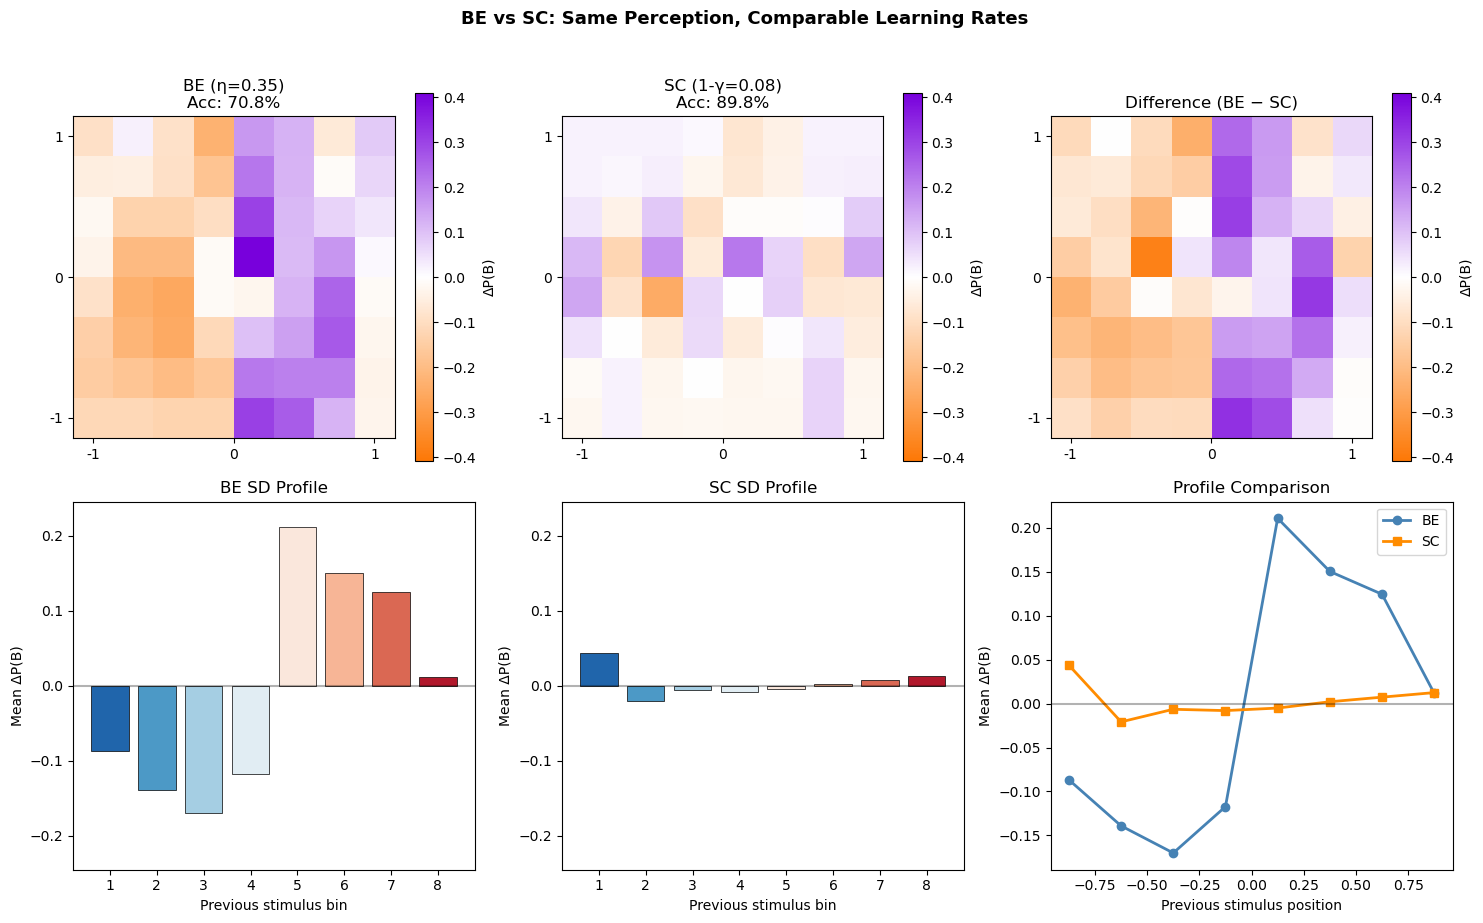

BE magnitude:         0.1335
SC magnitude:         0.0522
Difference magnitude: 0.1371


In [33]:
# ── Matched parameters ───────────────────────────────────────────────────────
SHARED = dict(sigma_percep=0.15, A_repulsion=0.10)
BE_PARAMS = dict(**SHARED, eta_learning=0.35, eta_relax=0.12)
SC_PARAMS = dict(**SHARED, gamma=0.92, sigma_update=0.30)

be_um, be_cm, be_ch, be_acc, be_info = simulate_be(**BE_PARAMS)
sc_um, sc_cm, sc_ch, sc_acc, sc_info = simulate_sc(**SC_PARAMS)

# Common colour scale
vmax = max(np.nanmax(np.abs(be_um)), np.nanmax(np.abs(sc_um)))
if np.isnan(vmax) or vmax == 0:
    vmax = 0.3
midpoints = be_info.get('midpoints', np.linspace(-0.875, 0.875, N_BINS))

# ── Top row: update matrices + difference ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (um, label, acc) in enumerate([
    (be_um, f'BE (\u03b7={BE_PARAMS["eta_learning"]})', be_acc),
    (sc_um, f'SC (1-\u03b3={1 - SC_PARAMS["gamma"]:.2f})', sc_acc),
    (be_um - sc_um, 'Difference (BE \u2212 SC)', None),
]):
    ax = axes[0, col]
    im = ax.imshow(um, cmap=UM_CMAP, vmin=-vmax, vmax=vmax,
                    origin='lower', aspect='equal')
    title = f'{label}\nAcc: {acc:.1%}' if acc is not None else label
    ax.set_title(title)
    ax.set_xticks([0, 3.5, 7]); ax.set_xticklabels(['-1', '0', '1'])
    ax.set_yticks([0, 3.5, 7]); ax.set_yticklabels(['-1', '0', '1'])
    plt.colorbar(im, ax=ax, label='\u0394P(B)')

# ── Bottom row: profiles and overlay ──────────────────────────────────────────
bar_colors = plt.cm.RdBu_r(np.linspace(0.1, 0.9, N_BINS))

for col, (um, label) in enumerate([
    (be_um, 'BE SD Profile'),
    (sc_um, 'SC SD Profile'),
]):
    ax = axes[1, col]
    profile = np.nanmean(um, axis=0)
    ax.bar(np.arange(N_BINS) + 1, profile, color=bar_colors,
           edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='k', alpha=0.3)
    ax.set_xlabel('Previous stimulus bin')
    ax.set_ylabel('Mean \u0394P(B)')
    ax.set_title(label)
    ax.set_ylim(-vmax * 0.6, vmax * 0.6)

# Overlay
ax = axes[1, 2]
ax.plot(midpoints, np.nanmean(be_um, axis=0), 'o-', color='steelblue',
        linewidth=2, label='BE')
ax.plot(midpoints, np.nanmean(sc_um, axis=0), 's-', color='darkorange',
        linewidth=2, label='SC')
ax.axhline(0, color='k', alpha=0.3)
ax.set_xlabel('Previous stimulus position')
ax.set_ylabel('Mean \u0394P(B)')
ax.set_title('Profile Comparison')
ax.legend()

fig.suptitle('BE vs SC: Same Perception, Comparable Learning Rates',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quantify
diff_mag = np.nanmean(np.abs(be_um - sc_um))
print(f"BE magnitude:         {np.nanmean(np.abs(be_um)):.4f}")
print(f"SC magnitude:         {np.nanmean(np.abs(sc_um)):.4f}")
print(f"Difference magnitude: {diff_mag:.4f}")

---

## 4. Phase Presets

What do the models look like at different learning stages?
Naive (high learning rate), Expert (low learning rate),
and Post-Shift (intermediate — model is re-adapting).

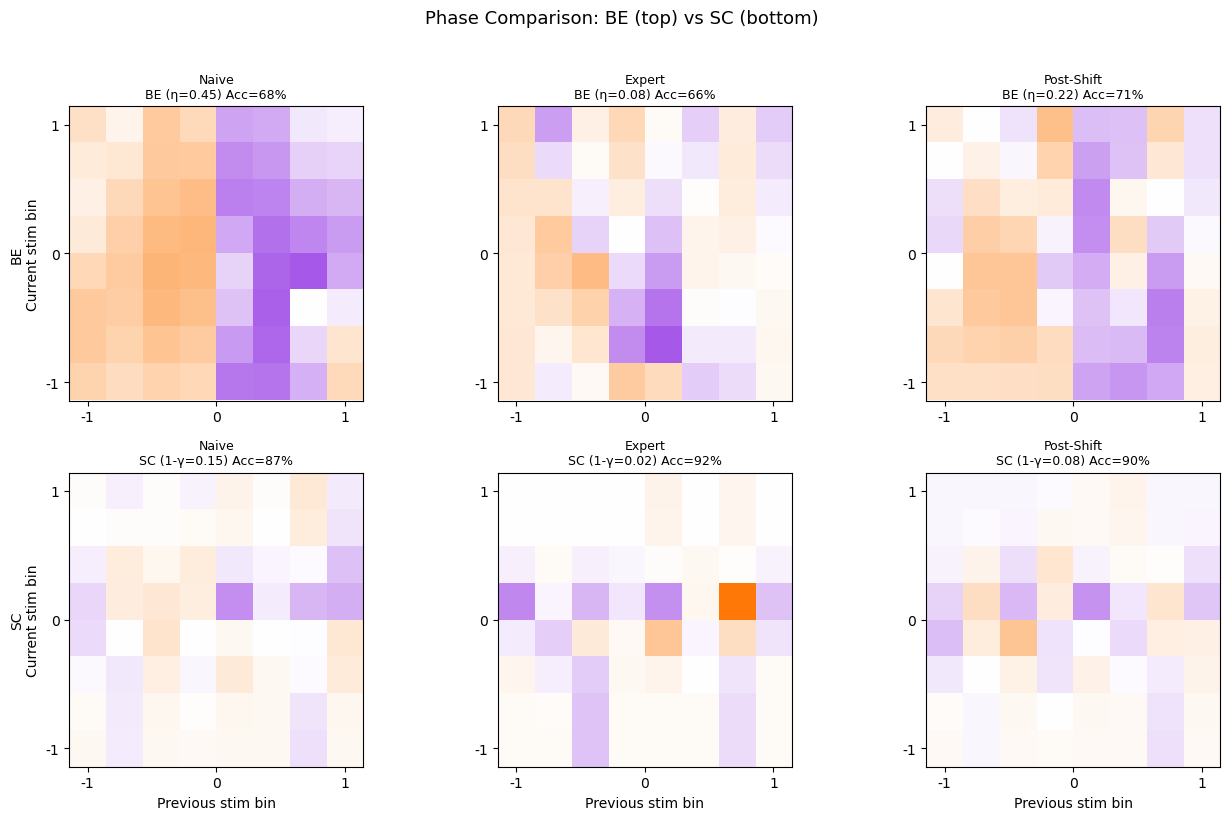

In [34]:
PRESETS = {
    'Naive': {
        'BE': dict(sigma_percep=0.20, A_repulsion=0.05, eta_learning=0.45, eta_relax=0.08),
        'SC': dict(sigma_percep=0.20, A_repulsion=0.05, gamma=0.85, sigma_update=0.35),
    },
    'Expert': {
        'BE': dict(sigma_percep=0.12, A_repulsion=0.15, eta_learning=0.08, eta_relax=0.15),
        'SC': dict(sigma_percep=0.12, A_repulsion=0.15, gamma=0.98, sigma_update=0.25),
    },
    'Post-Shift': {
        'BE': dict(sigma_percep=0.15, A_repulsion=0.12, eta_learning=0.22, eta_relax=0.10),
        'SC': dict(sigma_percep=0.15, A_repulsion=0.12, gamma=0.92, sigma_update=0.30),
    },
}

phase_names = list(PRESETS.keys())
n_phases = len(phase_names)

# Compute all
all_results = {}
for phase in phase_names:
    be_p = PRESETS[phase]['BE']
    sc_p = PRESETS[phase]['SC']
    all_results[(phase, 'BE')] = simulate_be(**be_p)
    all_results[(phase, 'SC')] = simulate_sc(**sc_p)

# Global colour scale
vmax = max(
    np.nanmax(np.abs(r[0]))
    for r in all_results.values()
    if not np.all(np.isnan(r[0]))
)
if np.isnan(vmax) or vmax == 0:
    vmax = 0.3

# Plot: rows = BE/SC, columns = phases
fig, axes = plt.subplots(2, n_phases, figsize=(4.5 * n_phases, 8))

for row, model in enumerate(['BE', 'SC']):
    colour = 'steelblue' if model == 'BE' else 'darkorange'
    for col, phase in enumerate(phase_names):
        ax = axes[row, col]
        um, _, _, acc, _ = all_results[(phase, model)]

        im = ax.imshow(um, cmap=UM_CMAP, vmin=-vmax, vmax=vmax,
                        origin='lower', aspect='equal')

        # Get learning rate label
        p = PRESETS[phase][model]
        if model == 'BE':
            lr_label = f'\u03b7={p["eta_learning"]}'
        else:
            lr_label = f'1-\u03b3={1 - p["gamma"]:.2f}'

        ax.set_title(f'{phase}\n{model} ({lr_label}) Acc={acc:.0%}', fontsize=9)
        ax.set_xticks([0, 3.5, 7]); ax.set_xticklabels(['-1', '0', '1'])
        ax.set_yticks([0, 3.5, 7]); ax.set_yticklabels(['-1', '0', '1'])

        if col == 0:
            ax.set_ylabel(f'{model}\nCurrent stim bin')
        if row == 1:
            ax.set_xlabel('Previous stim bin')

fig.suptitle('Phase Comparison: BE (top) vs SC (bottom)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Parameter Sweeps

Systematic exploration of how each parameter affects the update matrix.
BE and SC shown in parallel for shared parameters, separately for
model-specific parameters.

In [35]:
def sweep_and_plot(sim_fn, base_params, param_name, sweep_values,
                   model_label='', colour='steelblue'):
    """
    Sweep one parameter, show update matrices and profiles.
    """
    n = len(sweep_values)
    all_ums = []

    for val in sweep_values:
        p = dict(base_params)
        p[param_name] = float(val)
        um, _, _, acc, _ = sim_fn(**p)
        all_ums.append((val, um, acc))

    vmax = max(np.nanmax(np.abs(um)) for _, um, _ in all_ums
               if not np.all(np.isnan(um)))
    if np.isnan(vmax) or vmax == 0:
        vmax = 0.3

    fig, axes = plt.subplots(2, n, figsize=(3.5 * n, 7))

    for i, (val, um, acc) in enumerate(all_ums):
        # Top: matrix
        ax = axes[0, i]
        ax.imshow(um, cmap=UM_CMAP, vmin=-vmax, vmax=vmax,
                  origin='lower', aspect='equal')
        ax.set_title(f'{val:.3f}\nAcc={acc:.0%}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_ylabel('Current stim')

        # Bottom: profile
        ax = axes[1, i]
        profile = np.nanmean(um, axis=0)
        bar_colors = plt.cm.RdBu_r(np.linspace(0.1, 0.9, N_BINS))
        ax.bar(np.arange(N_BINS) + 1, profile, color=bar_colors,
               edgecolor='black', linewidth=0.5)
        ax.axhline(0, color='k', alpha=0.3)
        ax.set_ylim(-vmax * 0.6, vmax * 0.6)
        ax.set_xticks([])
        if i == 0:
            ax.set_ylabel('Mean \u0394P(B)')

    fig.suptitle(f'{model_label}: {param_name} sweep', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

print("Sweep function defined.")

Sweep function defined.


### 5.1 Shared parameter: A_repulsion

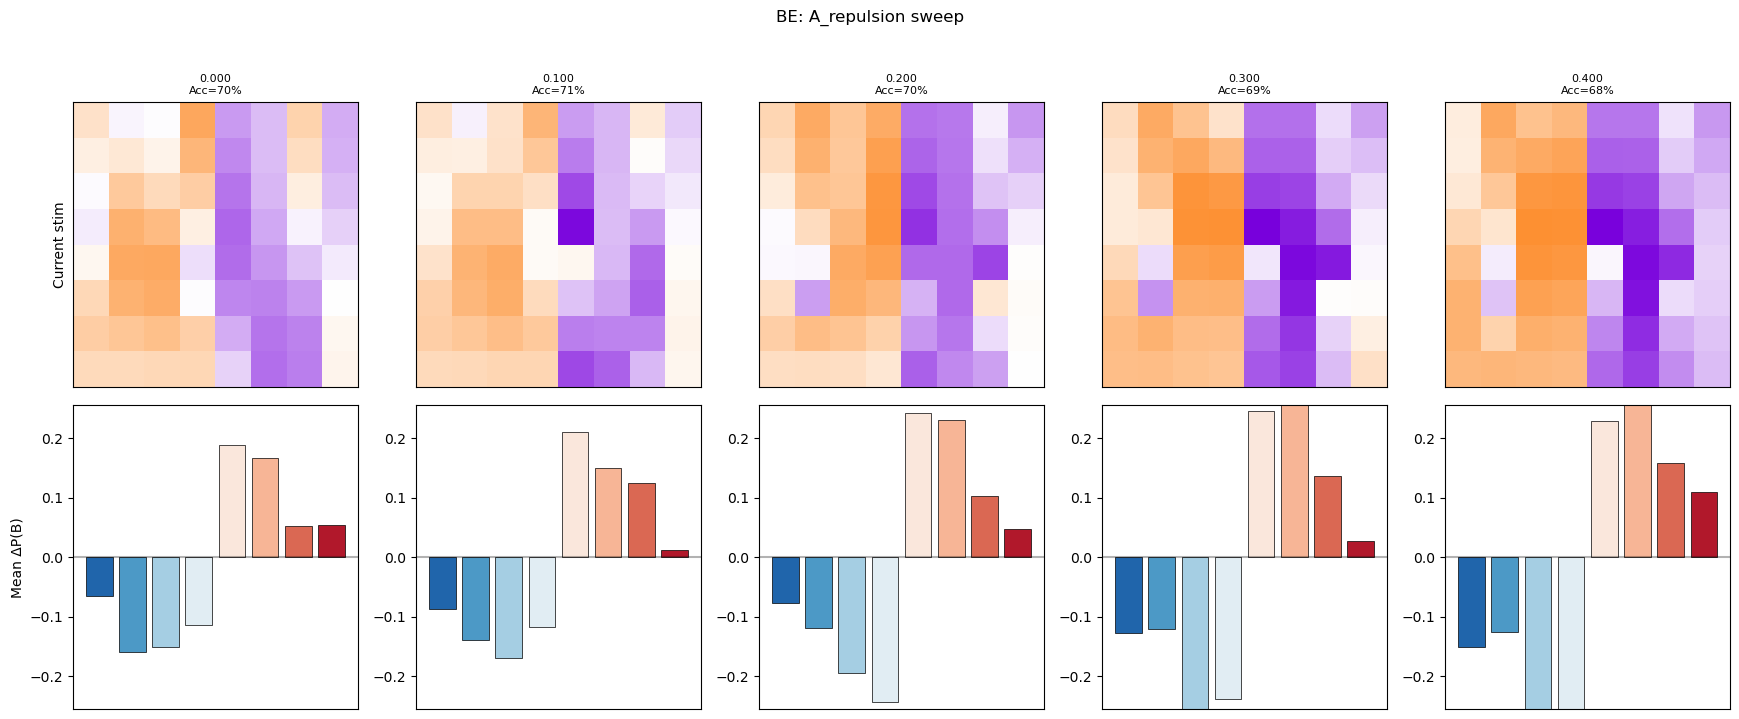

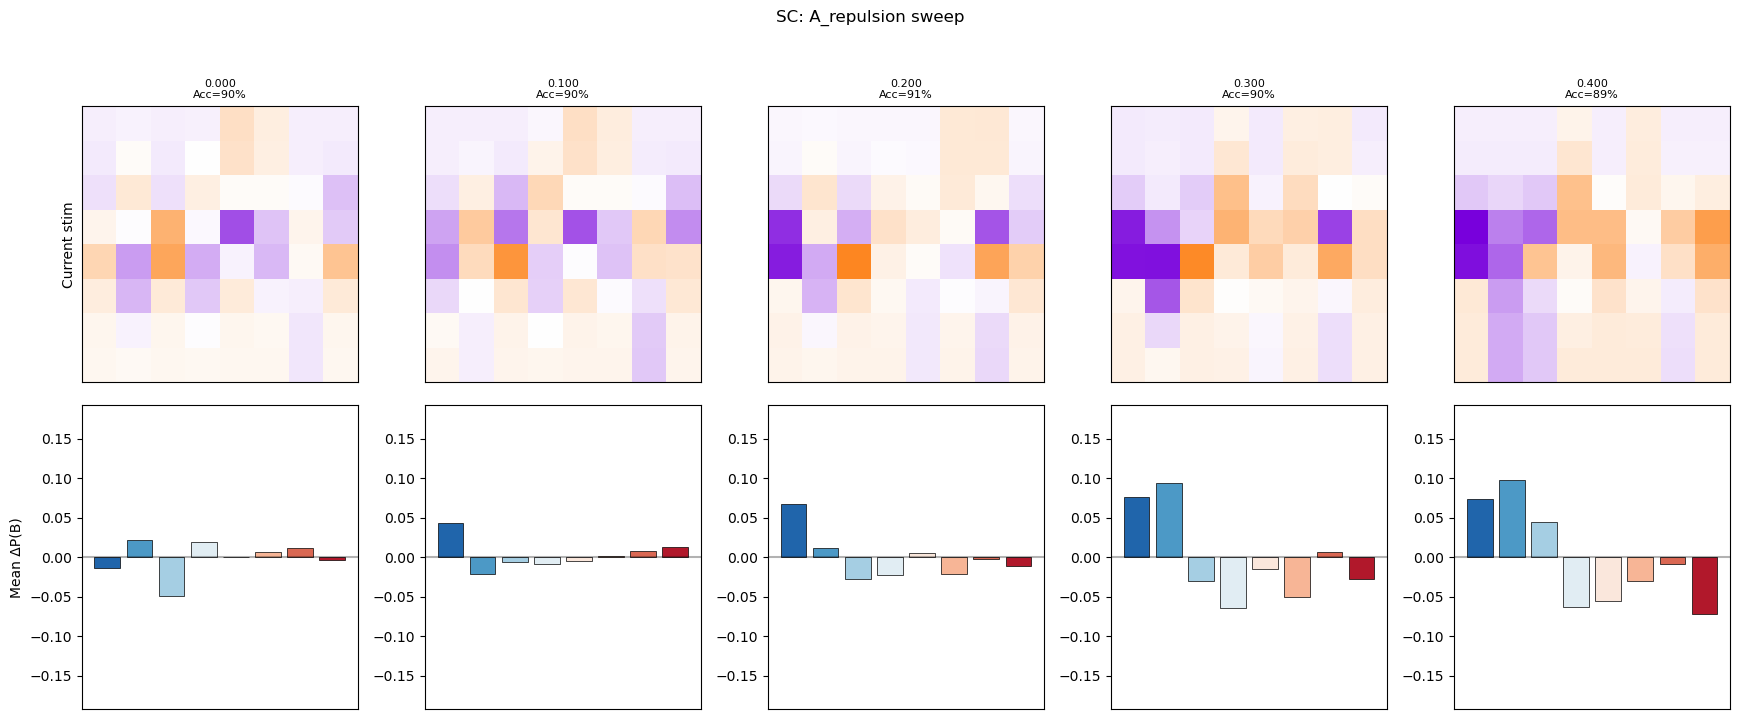

In [36]:
A_VALS = [0.0, 0.1, 0.2, 0.3, 0.4]
BE_BASE = dict(sigma_percep=0.15, A_repulsion=0.10, eta_learning=0.35, eta_relax=0.12)
SC_BASE = dict(sigma_percep=0.15, A_repulsion=0.10, gamma=0.92, sigma_update=0.30)

sweep_and_plot(simulate_be, BE_BASE, 'A_repulsion', A_VALS,
               model_label='BE', colour='steelblue')
sweep_and_plot(simulate_sc, SC_BASE, 'A_repulsion', A_VALS,
               model_label='SC', colour='darkorange')

### 5.2 Learning rate: eta_learning (BE) vs gamma (SC)

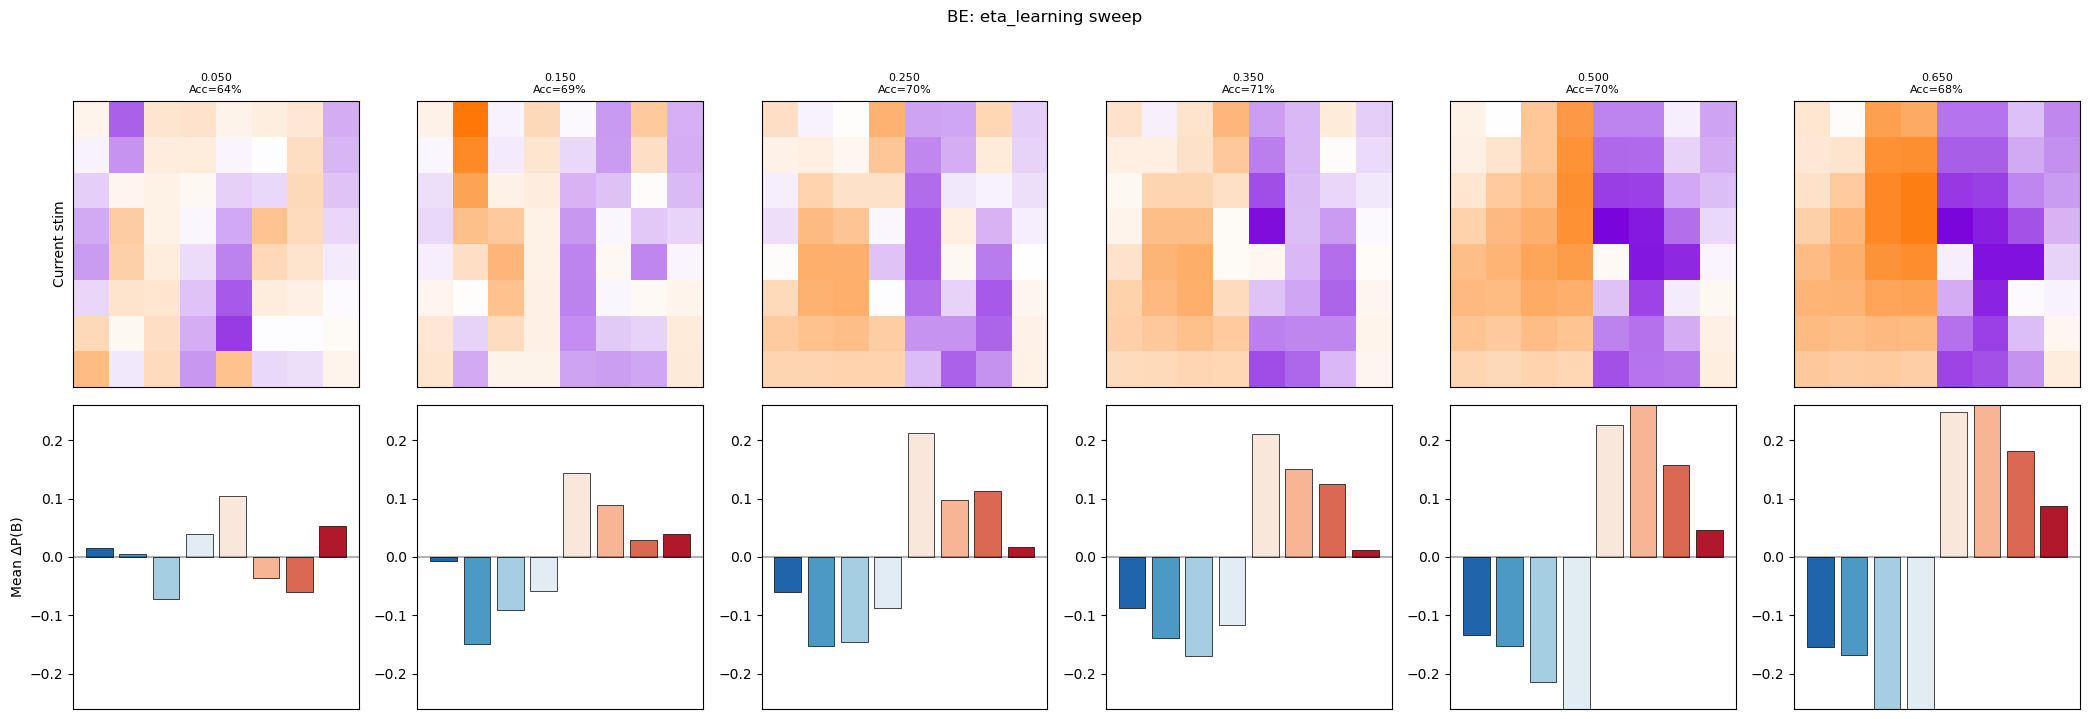

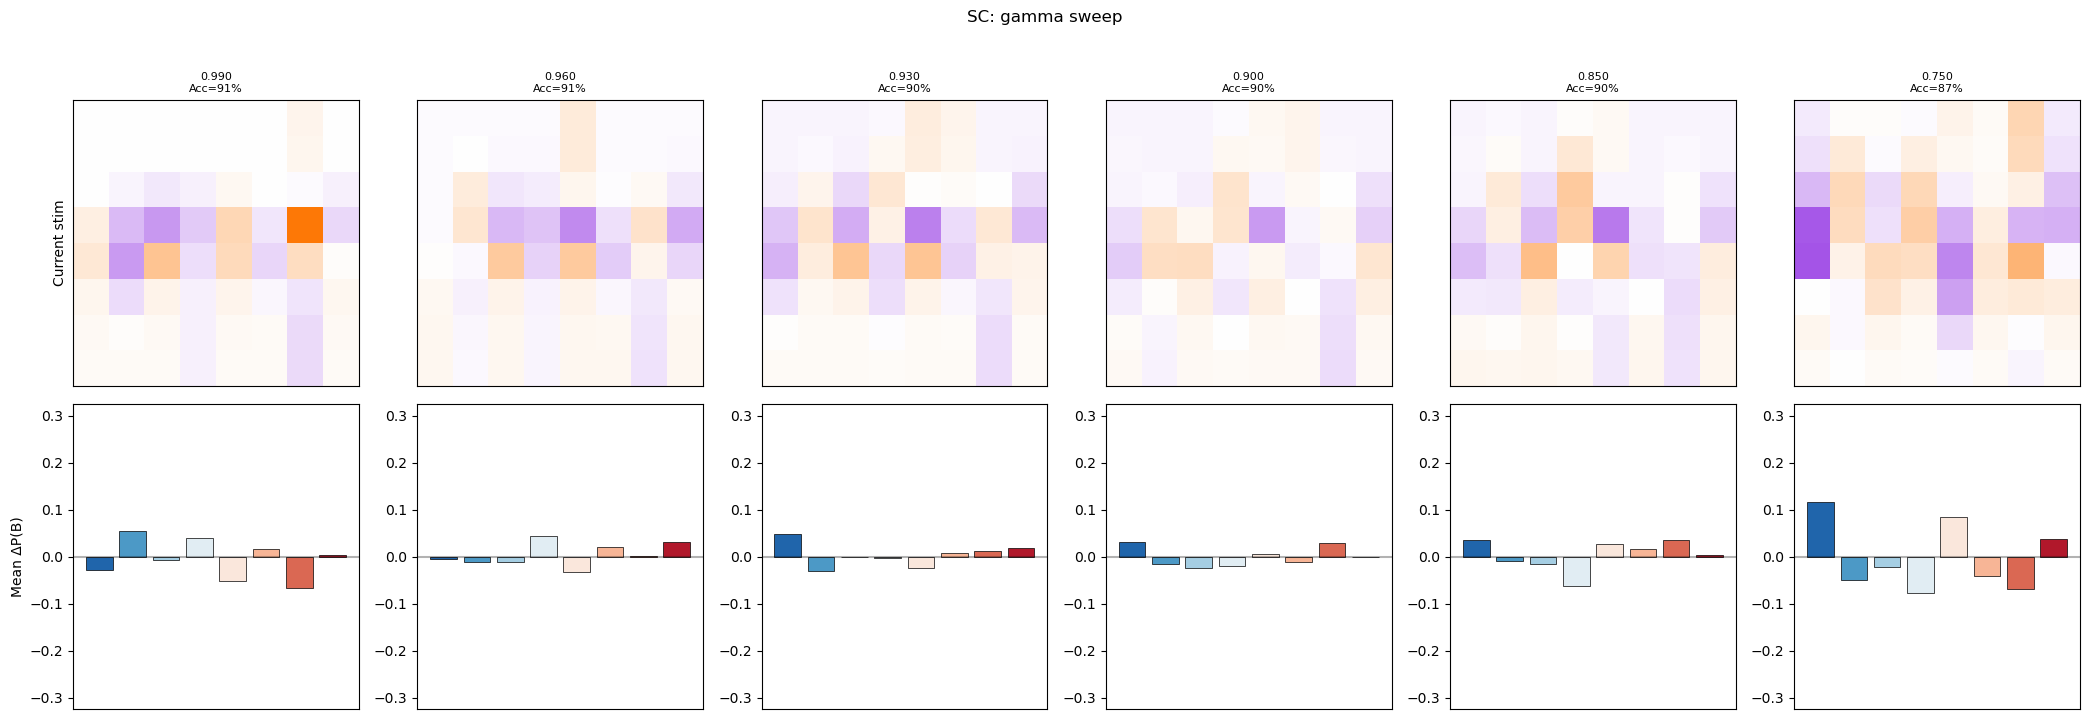

In [37]:
# BE: higher eta = more learning
sweep_and_plot(simulate_be, BE_BASE, 'eta_learning',
               [0.05, 0.15, 0.25, 0.35, 0.50, 0.65],
               model_label='BE')

# SC: lower gamma = more learning (show as decreasing gamma)
sweep_and_plot(simulate_sc, SC_BASE, 'gamma',
               [0.99, 0.96, 0.93, 0.90, 0.85, 0.75],
               model_label='SC')

### 5.3 Model-specific parameters

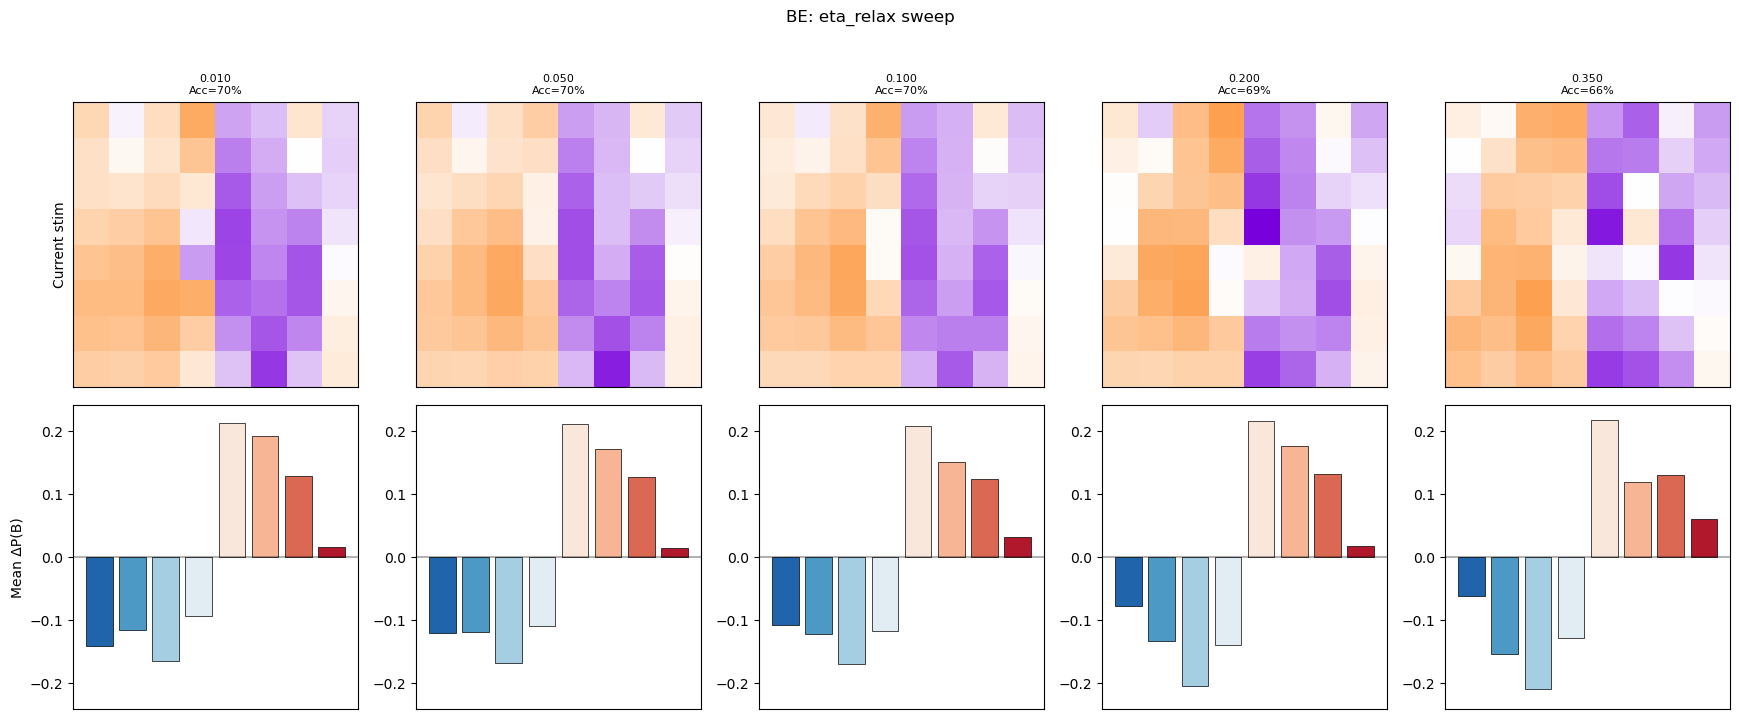

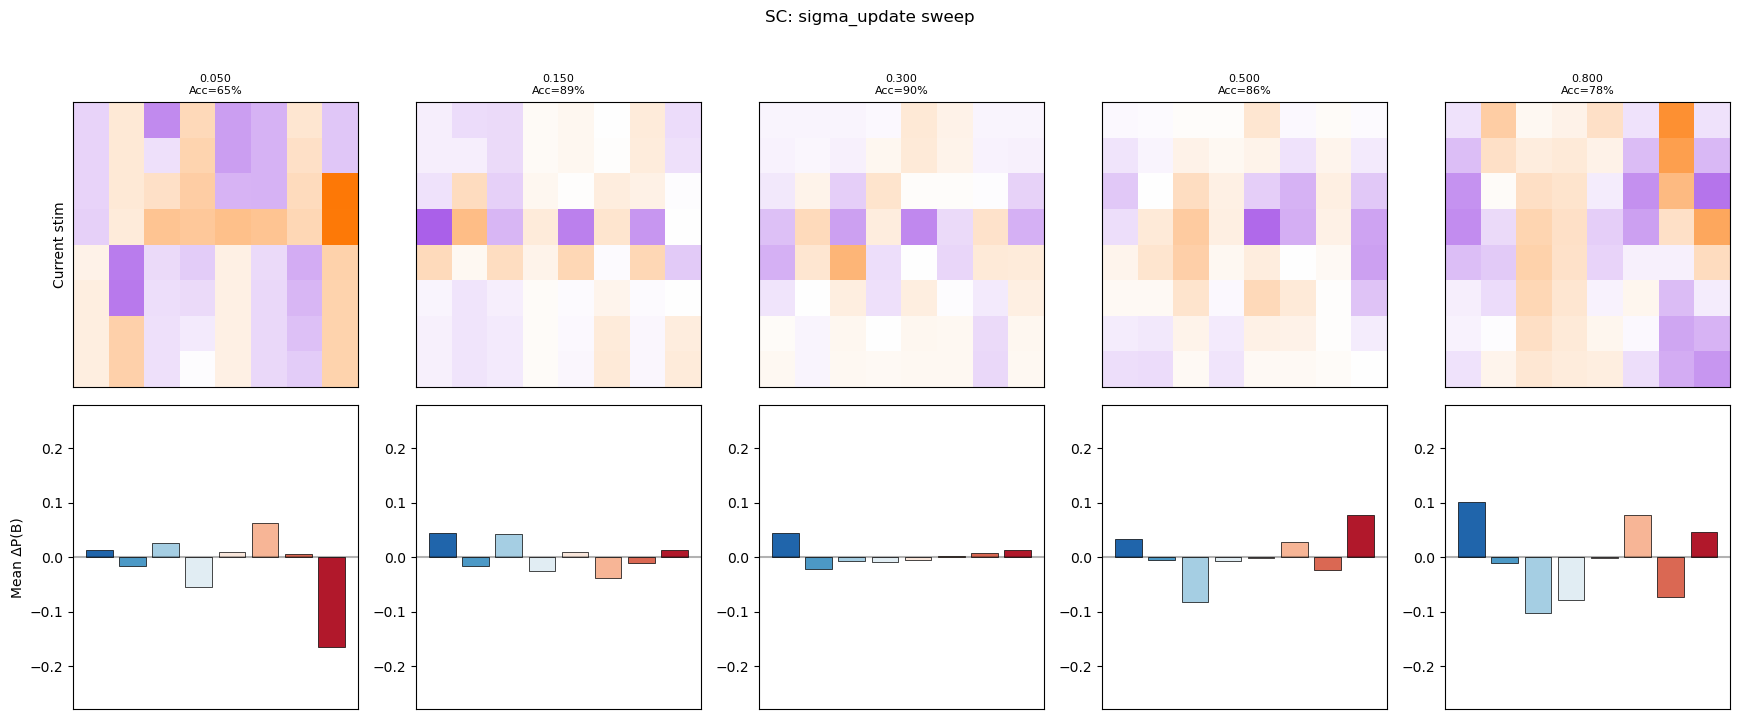

In [38]:
# BE: eta_relax (relaxation toward uniform)
sweep_and_plot(simulate_be, BE_BASE, 'eta_relax',
               [0.01, 0.05, 0.10, 0.20, 0.35],
               model_label='BE')

# SC: sigma_update (update bump width)
sweep_and_plot(simulate_sc, SC_BASE, 'sigma_update',
               [0.05, 0.15, 0.30, 0.50, 0.80],
               model_label='SC')

---

## 6. 2D Parameter Grid (BE)

Full update matrix for each combination of two BE parameters.
This is computationally expensive (8×8 = 64 simulations) so only
done for BE. Run SC version separately if needed.

In [39]:
def plot_2d_grid(sim_fn, base_params, p1_name, p1_vals, p2_name, p2_vals,
                 model_label=''):
    """Compute and plot n1 x n2 grid of update matrices."""
    n1, n2 = len(p1_vals), len(p2_vals)
    matrices = np.full((n2, n1, N_BINS, N_BINS), np.nan)

    print(f"Computing {n1}×{n2} = {n1*n2} simulations...")
    for i, v2 in enumerate(p2_vals):
        for j, v1 in enumerate(p1_vals):
            p = dict(base_params)
            p[p1_name] = float(v1)
            p[p2_name] = float(v2)
            try:
                um, _, _, _, _ = sim_fn(**p)
                matrices[i, j] = um
            except Exception as e:
                print(f"  Failed at {p1_name}={v1:.3f}, {p2_name}={v2:.3f}: {e}")

    vmax = np.nanmax(np.abs(matrices))
    if np.isnan(vmax) or vmax == 0:
        vmax = 0.3

    fig, axes = plt.subplots(n2, n1, figsize=(2.2 * n1, 2.2 * n2))

    for i in range(n2):
        for j in range(n1):
            ax = axes[i, j]
            ax.imshow(matrices[i, j], cmap=UM_CMAP, vmin=-vmax, vmax=vmax,
                      origin='lower', aspect='equal')
            ax.set_xticks([]); ax.set_yticks([])
            if i == n2 - 1:
                ax.set_xlabel(f'{p1_vals[j]:.2f}', fontsize=8)
            if j == 0:
                ax.set_ylabel(f'{p2_vals[i]:.2f}', fontsize=8)

    fig.text(0.5, 0.02, p1_name, ha='center', fontsize=12)
    fig.text(0.02, 0.5, p2_name, va='center', rotation='vertical', fontsize=12)

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=UM_CMAP, norm=plt.Normalize(-vmax, vmax))
    fig.colorbar(sm, cax=cbar_ax, label='\u0394P(B)')

    fig.suptitle(f'{model_label}: {p1_name} vs {p2_name}', fontsize=13, y=0.98)
    plt.subplots_adjust(left=0.08, right=0.9, bottom=0.08, top=0.93,
                        wspace=0.05, hspace=0.05)
    plt.show()

    return matrices

Computing 8×8 = 64 simulations...


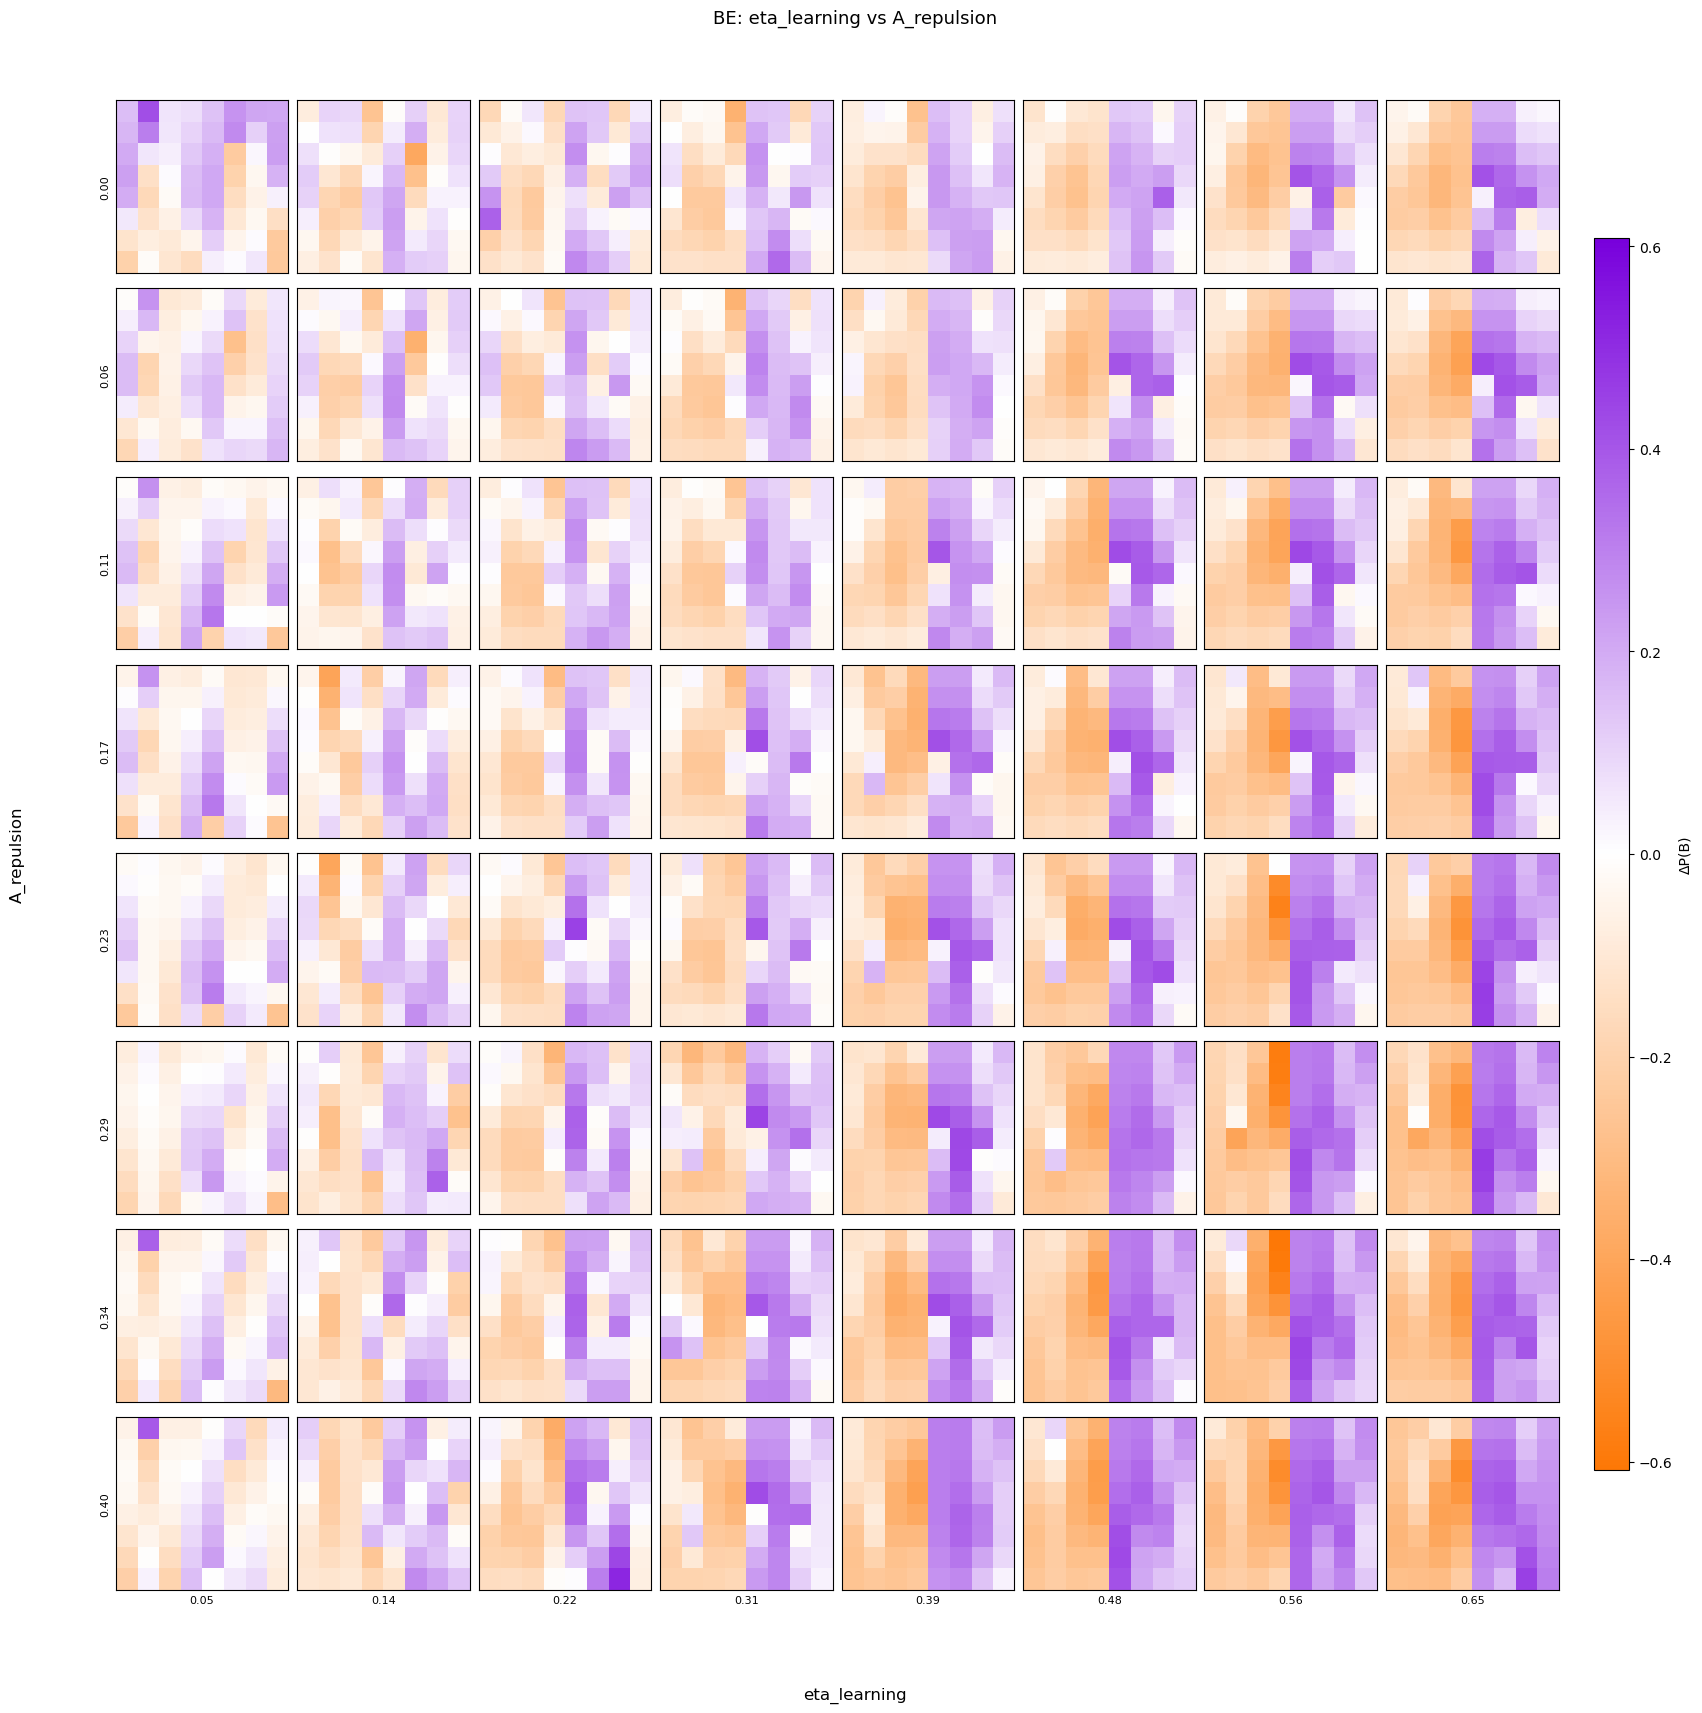

In [40]:
matrices = plot_2d_grid(
    simulate_be, BE_BASE,
    p1_name='eta_learning', p1_vals=np.linspace(0.05, 0.65, 8),
    p2_name='A_repulsion', p2_vals=np.linspace(0.0, 0.4, 8),
    model_label='BE',
)

Computing 8×8 = 64 simulations...


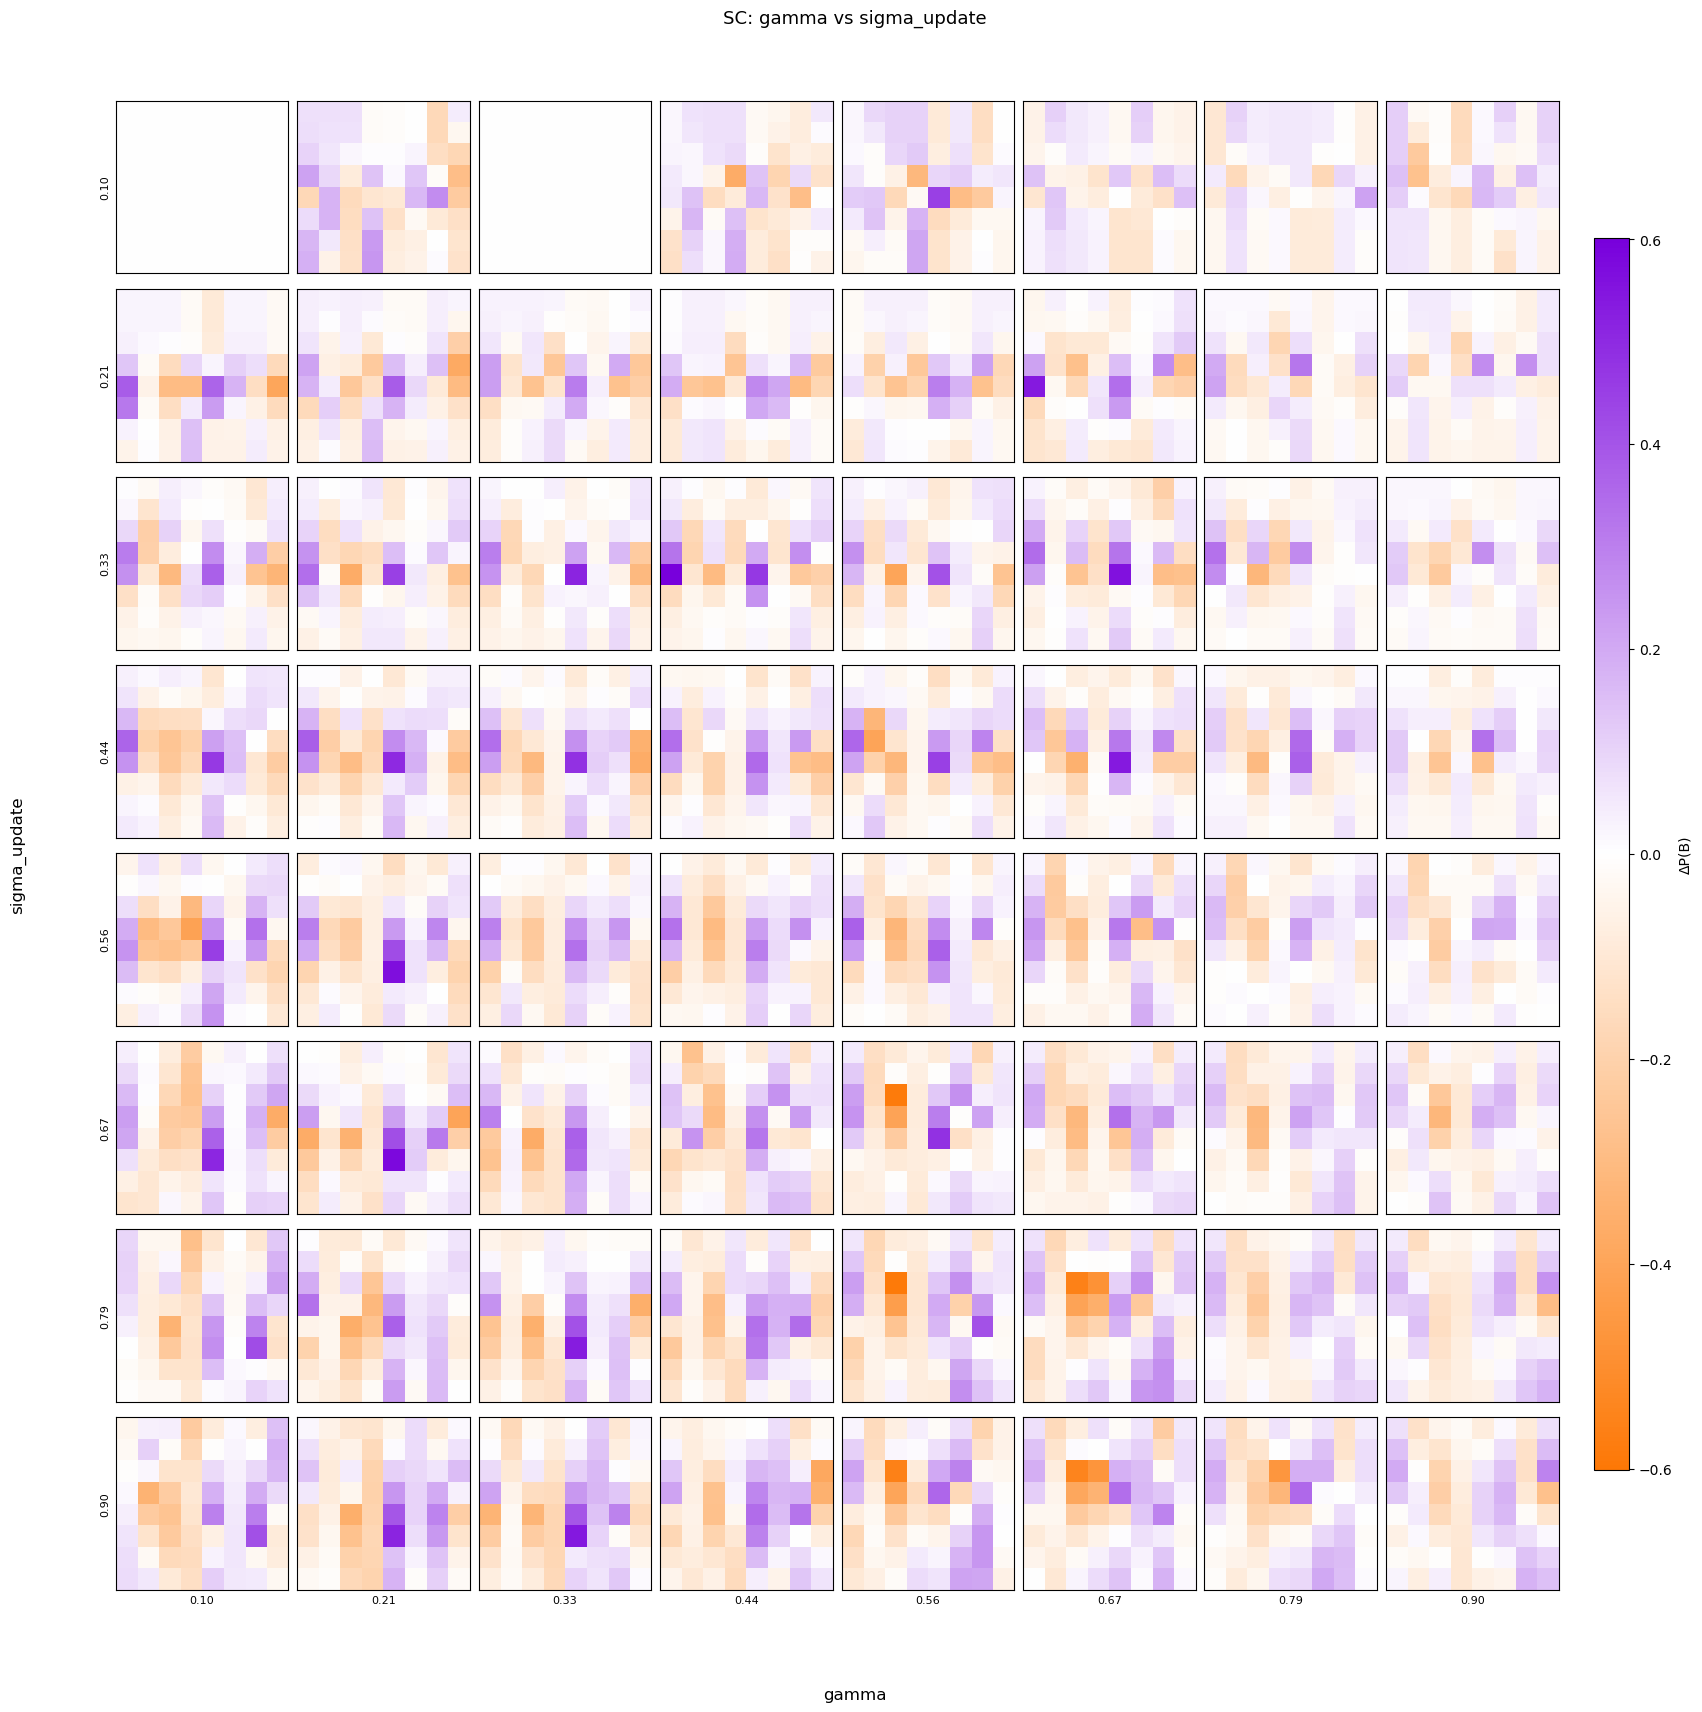

In [41]:
matrices = plot_2d_grid(
    simulate_sc, SC_BASE,
    p1_name='gamma', p1_vals=np.linspace(0.1, 0.9, 8), # gamma, sigma_update, sigma_percep, A_repulsion
    p2_name='sigma_update', p2_vals=np.linspace(0.1, 0.9, 8),
    model_label='SC',
)

---
## 7. Distribution Shift Predictions

**Question:** What do the BE and SC models predict will happen when the
stimulus distribution shifts?

We simulate both models through the full experimental sequence:

    Uniform (30 sessions) → Hard-A (10) → Hard-B (10) → Hard-A (10)

with state chaining across sessions. The model's internal state
(belief distribution for BE, category distributions for SC) carries
forward — it doesn't reset between sessions.

**Key predictions to look for:**
1. Both models should show an accuracy drop at each shift
2. Recovery timecourse may differ between BE and SC
3. The update matrix pattern should change post-shift
4. The second exposure to Hard-A should show faster recovery
   (the model has meta-experience, even if parameters are fixed)
5. BE and SC should produce *different* stat trajectories —
   if they don't, we can't distinguish them from post-shift behaviour

In [42]:
from analysis.stimulus_distribution import sample_distribution
from behav_utils.analysis.summary_stats import compute_summary_stats

In [43]:
# ── Shift sequence definition ────────────────────────────────────────────────
TRIALS_PER_SESSION = 200
SHIFT_SEQUENCE = [
    ('Uniform', 30),
    ('Hard-A',  10),
    ('Hard-B',  10),
    ('Hard-A',  10),
]

# Representative parameters (pick values that produce expert-like
# performance under Uniform — adjust based on 0b interactive exploration)
BE_PARAMS = BEParams(
    sigma_percep=0.15,
    A_repulsion=0.10,
    eta_learning=0.35,
    eta_relax=0.12,
)

SC_PARAMS = SCParams(
    sigma_percep=0.15,
    A_repulsion=0.10,
    gamma=0.95,
    sigma_update=0.30,
)

total_sessions = sum(n for _, n in SHIFT_SEQUENCE)
print(f'Shift sequence: {total_sessions} sessions total')
for dist, n in SHIFT_SEQUENCE:
    print(f'  {dist}: {n} sessions × {TRIALS_PER_SESSION} trials')

Shift sequence: 60 sessions total
  Uniform: 30 sessions × 200 trials
  Hard-A: 10 sessions × 200 trials
  Hard-B: 10 sessions × 200 trials
  Hard-A: 10 sessions × 200 trials


In [44]:
def simulate_shift_sequence(
    model_type,
    params,
    shift_sequence,
    trials_per_session,
    burn_in=BURN_IN,
    seed=SEED,
    n_bins=N_BINS,
):
    """
    Simulate a model through a multi-phase distribution shift sequence.
    
    Returns per-session results: stats, update matrices, metadata.
    State chains across sessions (no reset).
    """
    rng = np.random.default_rng(seed)
    
    # Initialise model state
    if model_type == 'BE':
        state = BEModel.create_initial_state(
            burn_in=burn_in, params=params, seed=seed,
        )
    else:
        state = SCModel.create_initial_state(
            params=params, burn_in=burn_in, seed=seed,
        )
    
    results = []
    session_idx = 0
    
    for distribution, n_sessions in shift_sequence:
        for s in range(n_sessions):
            # Generate stimuli for this session
            stimuli, categories = sample_distribution(
                trials_per_session, distribution, rng=rng,
            )
            
            # Simulate
            if model_type == 'BE':
                choices, p_B, state, trace = BEModel.simulate_session(
                    params, state, stimuli, categories, rng,
                    return_history=True,
                )
            else:
                choices, p_B, state, trace = SCModel.simulate_session(
                    params, state, stimuli, categories, rng,
                    return_history=True,
                )
            
            # Compute summary stats
            no_resp = np.isnan(choices)
            valid = ~no_resp
            stats = compute_summary_stats(
                choices[valid], stimuli[valid], categories[valid],
                stat_names=['accuracy', 'psychometric', 'recency',
                            'stimulus_recency', 'win_stay', 'side_bias',
                            'choice_entropy'],
                return_dict=True,
            )
            # Flatten nested dicts
            flat_stats = {}
            for k, v in stats.items():
                if isinstance(v, dict):
                    flat_stats.update(v)
                elif not isinstance(v, np.ndarray):
                    flat_stats[k] = v
            
            # Compute update matrix
            nbs = np.ones(len(stimuli), dtype=bool)
            nbs[0] = False
            um, cm, um_info = compute_update_matrix(
                stimuli, choices, categories,
                n_bins=n_bins, trial_filter='post_correct',
                no_response=no_resp, not_blockstart=nbs,
            )
            
            results.append({
                'session_idx': session_idx,
                'distribution': distribution,
                'update_matrix': um,
                'conditional_matrix': cm,
                **flat_stats,
            })
            session_idx += 1
    
    return pd.DataFrame(results)

print('simulate_shift_sequence defined')

simulate_shift_sequence defined


In [45]:
# Run both models
import pandas as pd

be_results = simulate_shift_sequence('BE', BE_PARAMS, SHIFT_SEQUENCE, TRIALS_PER_SESSION)
sc_results = simulate_shift_sequence('SC', SC_PARAMS, SHIFT_SEQUENCE, TRIALS_PER_SESSION)

print(f'BE: {len(be_results)} sessions simulated')
print(f'SC: {len(sc_results)} sessions simulated')

BE: 60 sessions simulated
SC: 60 sessions simulated


### 7.1 Stat Trajectories Across the Shift

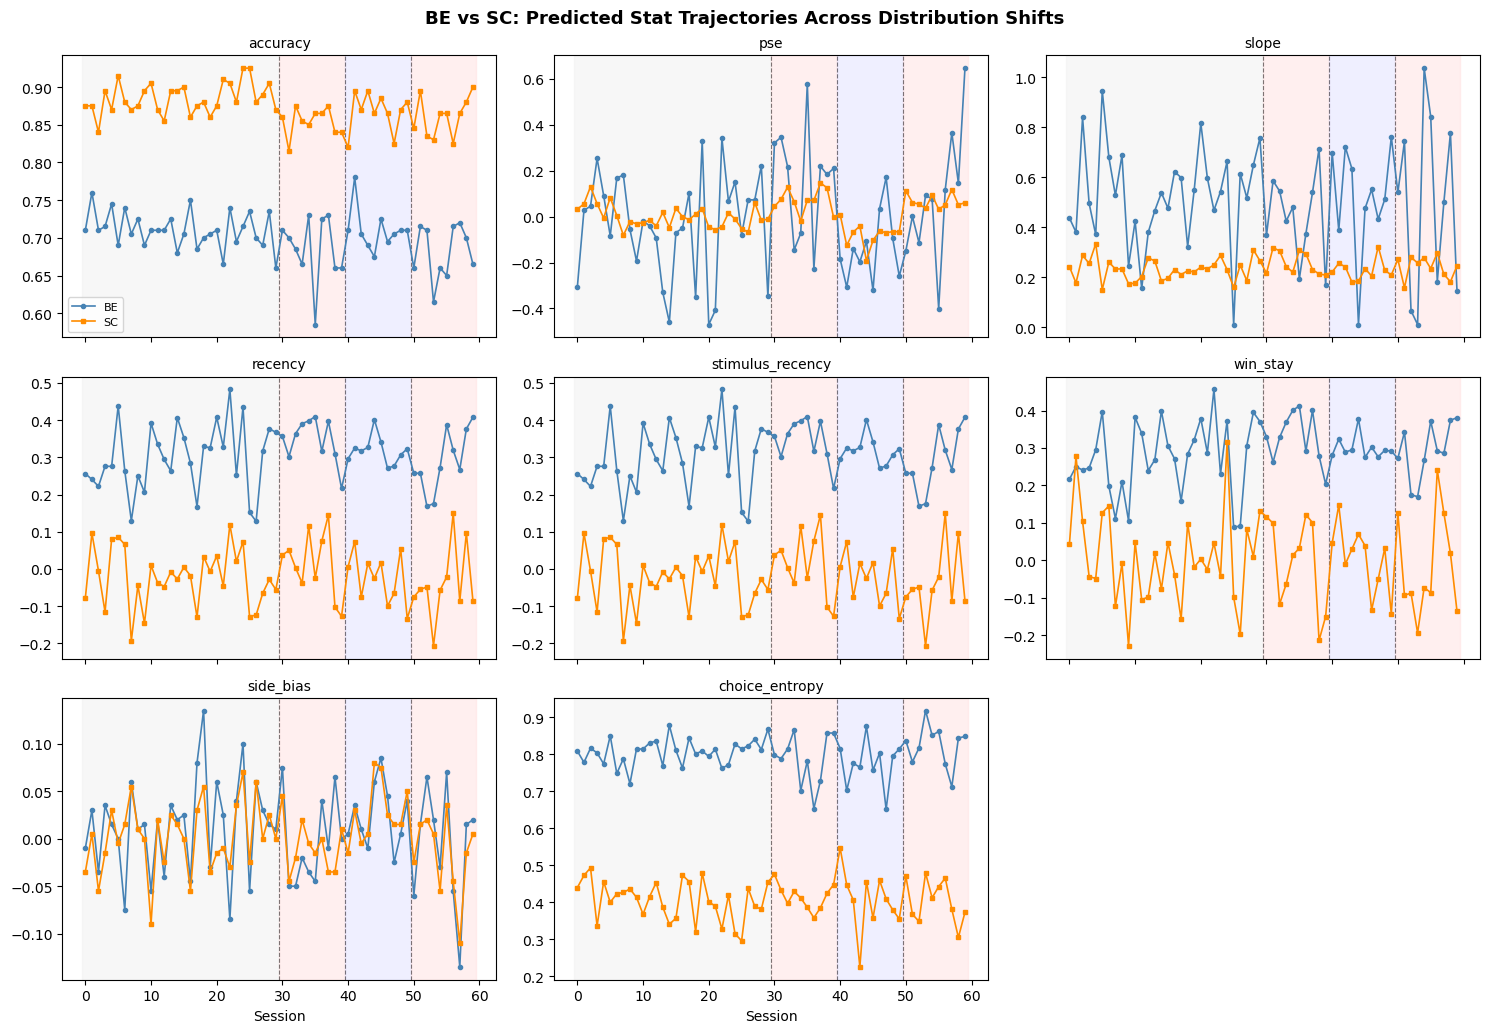

In [46]:
TRACK_STATS = ['accuracy', 'pse', 'slope', 'recency', 'stimulus_recency',
               'win_stay', 'side_bias', 'choice_entropy']

# Build shift boundary positions for vertical lines
shift_boundaries = []
cumulative = 0
for dist, n in SHIFT_SEQUENCE[:-1]:
    cumulative += n
    shift_boundaries.append(cumulative)

# Phase labels for background shading
phase_spans = []
cumulative = 0
for dist, n in SHIFT_SEQUENCE:
    phase_spans.append((cumulative, cumulative + n, dist))
    cumulative += n

DIST_COLOURS = {'Uniform': '#f0f0f0', 'Hard-A': '#ffe0e0', 'Hard-B': '#e0e0ff'}


def plot_trajectories(be_df, sc_df, stats, title=''):
    """Plot stat trajectories for both models with phase shading."""
    n_stats = len(stats)
    n_cols = min(3, n_stats)
    n_rows = int(np.ceil(n_stats / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(5 * n_cols, 3.5 * n_rows),
                              sharex=True)
    axes = np.atleast_2d(axes)
    
    for idx, stat in enumerate(stats):
        row, col = divmod(idx, n_cols)
        ax = axes[row, col]
        
        # Phase shading
        for start, end, dist in phase_spans:
            ax.axvspan(start - 0.5, end - 0.5,
                       color=DIST_COLOURS.get(dist, '#f0f0f0'),
                       alpha=0.5, zorder=0)
        
        # Shift boundaries
        for b in shift_boundaries:
            ax.axvline(b - 0.5, color='black', ls='--', lw=0.8, alpha=0.5)
        
        # Data
        if stat in be_df.columns:
            ax.plot(be_df['session_idx'], be_df[stat],
                    'o-', ms=3, lw=1.2, color='steelblue', label='BE')
        if stat in sc_df.columns:
            ax.plot(sc_df['session_idx'], sc_df[stat],
                    's-', ms=3, lw=1.2, color='darkorange', label='SC')
        
        ax.set_title(stat, fontsize=10)
        if row == n_rows - 1:
            ax.set_xlabel('Session')
        if idx == 0:
            ax.legend(fontsize=8)
    
    # Hide unused axes
    for idx in range(n_stats, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row, col].set_visible(False)
    
    if title:
        fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig, axes


fig, axes = plot_trajectories(
    be_results, sc_results, TRACK_STATS,
    title='BE vs SC: Predicted Stat Trajectories Across Distribution Shifts',
)
plt.show()

### 7.2 Update Matrices at Key Phases

Compare update matrices at four timepoints:
1. **Late Uniform** (expert baseline)
2. **Early Hard-A** (first shift, disrupted)
3. **Late Hard-A** (recovered)
4. **Early Hard-A 2nd exposure** (does meta-experience help?)

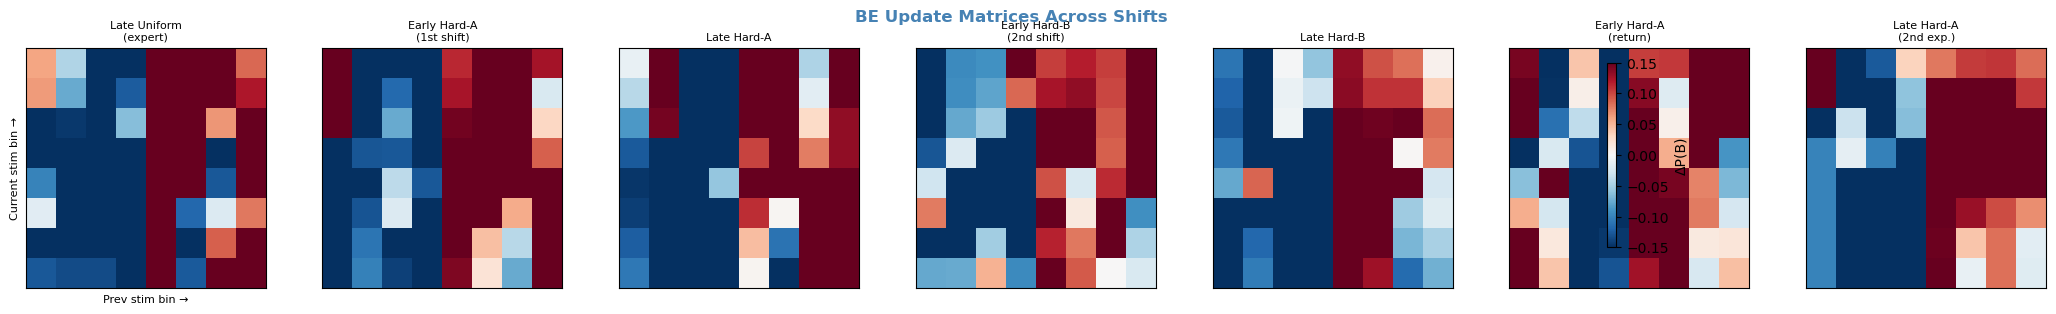

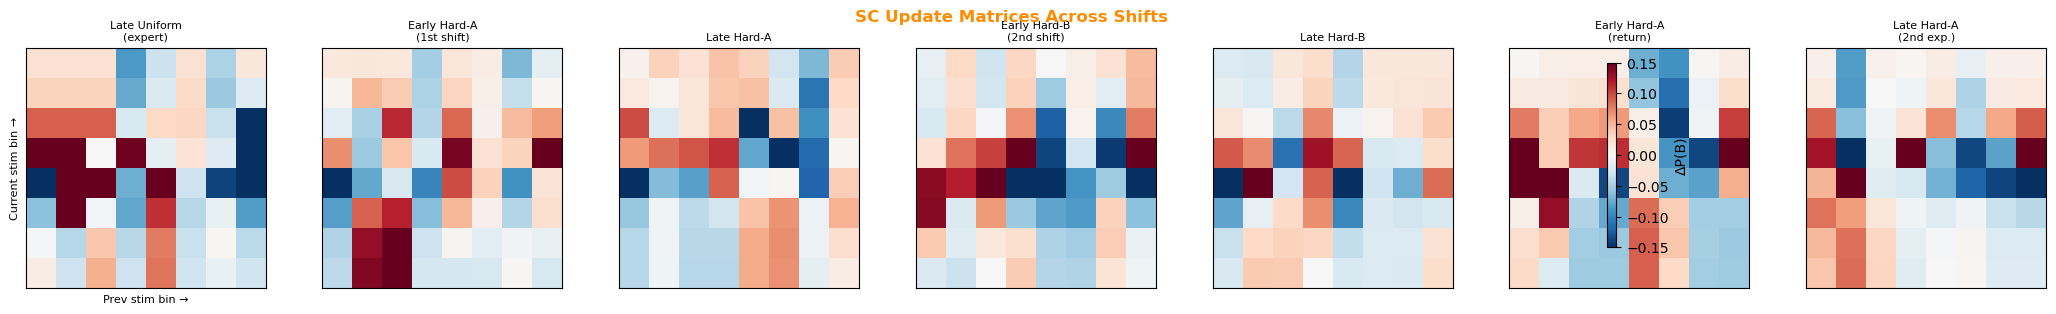

In [47]:
def get_phase_um(df, session_range, n_pool=3):
    """Average update matrices over a range of sessions."""
    subset = df[(df['session_idx'] >= session_range[0]) &
                (df['session_idx'] < session_range[1])]
    matrices = [row['update_matrix'] for _, row in subset.iterrows()
                if isinstance(row['update_matrix'], np.ndarray)]
    if not matrices:
        return np.full((N_BINS, N_BINS), np.nan)
    stacked = np.stack(matrices)
    return np.nanmean(stacked, axis=0)


# Define phase windows (session indices)
# Uniform: 0–29, Hard-A1: 30–39, Hard-B: 40–49, Hard-A2: 50–59
PHASE_WINDOWS = {
    'Late Uniform\n(expert)':     (27, 30),
    'Early Hard-A\n(1st shift)':  (30, 33),
    'Late Hard-A':                (37, 40),
    'Early Hard-B\n(2nd shift)':  (40, 43),
    'Late Hard-B':                (47, 50),
    'Early Hard-A\n(return)':     (50, 53),
    'Late Hard-A\n(2nd exp.)':    (57, 60),
}


def plot_phase_ums(df, model_name, colour, vmax=0.15):
    """Plot update matrices at key phases for one model."""
    n_phases = len(PHASE_WINDOWS)
    fig, axes = plt.subplots(1, n_phases, figsize=(3 * n_phases, 3))
    
    for ax, (label, window) in zip(axes, PHASE_WINDOWS.items()):
        um = get_phase_um(df, window)
        im = ax.imshow(um, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                        origin='lower', aspect='equal')
        ax.set_title(label, fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    
    axes[0].set_ylabel(f'Current stim bin →', fontsize=8)
    axes[0].set_xlabel(f'Prev stim bin →', fontsize=8)
    
    fig.suptitle(f'{model_name} Update Matrices Across Shifts',
                 fontsize=12, fontweight='bold', color=colour)
    fig.colorbar(im, ax=axes, shrink=0.8, label='ΔP(B)')
    plt.tight_layout()
    return fig


fig_be = plot_phase_ums(be_results, 'BE', 'steelblue')
plt.show()

fig_sc = plot_phase_ums(sc_results, 'SC', 'darkorange')
plt.show()

### 7.3 Direct BE vs SC Comparison per Phase

For each phase: BE update matrix, SC update matrix, and their difference.

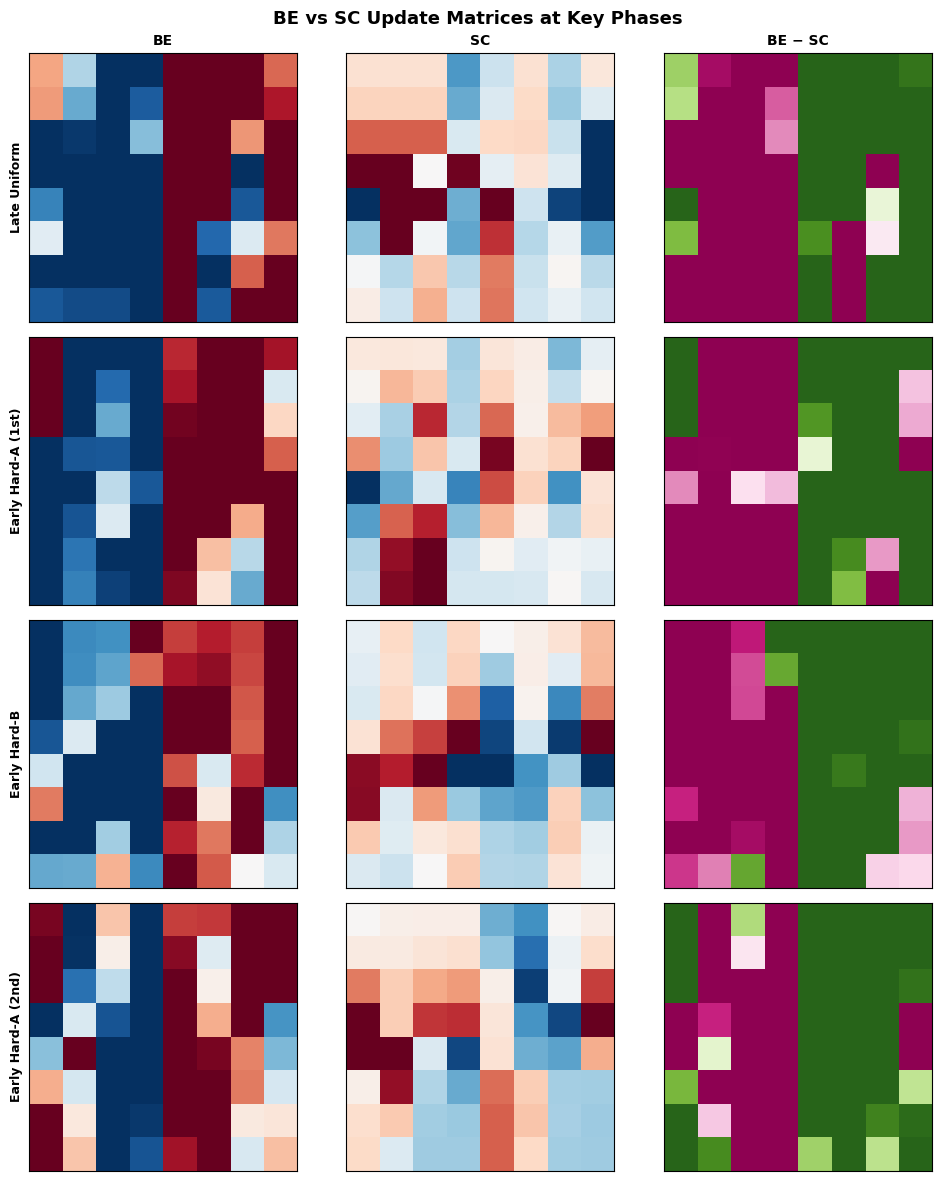

In [48]:
# Side-by-side: BE vs SC vs difference at key phases
KEY_PHASES = {
    'Late Uniform':       (27, 30),
    'Early Hard-A (1st)': (30, 33),
    'Early Hard-B':       (40, 43),
    'Early Hard-A (2nd)': (50, 53),
}

fig, axes = plt.subplots(len(KEY_PHASES), 3,
                          figsize=(10, 3 * len(KEY_PHASES)))
vmax = 0.15

for row, (label, window) in enumerate(KEY_PHASES.items()):
    be_um = get_phase_um(be_results, window)
    sc_um = get_phase_um(sc_results, window)
    diff = be_um - sc_um
    
    for col, (data, subtitle, cmap) in enumerate([
        (be_um, 'BE', 'RdBu_r'),
        (sc_um, 'SC', 'RdBu_r'),
        (diff,  'BE − SC', 'PiYG'),
    ]):
        ax = axes[row, col]
        vm = vmax if col < 2 else vmax / 2
        im = ax.imshow(data, cmap=cmap, vmin=-vm, vmax=vm,
                        origin='lower', aspect='equal')
        if row == 0:
            ax.set_title(subtitle, fontsize=10, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
    
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight='bold')

fig.suptitle('BE vs SC Update Matrices at Key Phases',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 Recovery Dynamics: Quantitative Comparison

How quickly does each model recover after each shift?

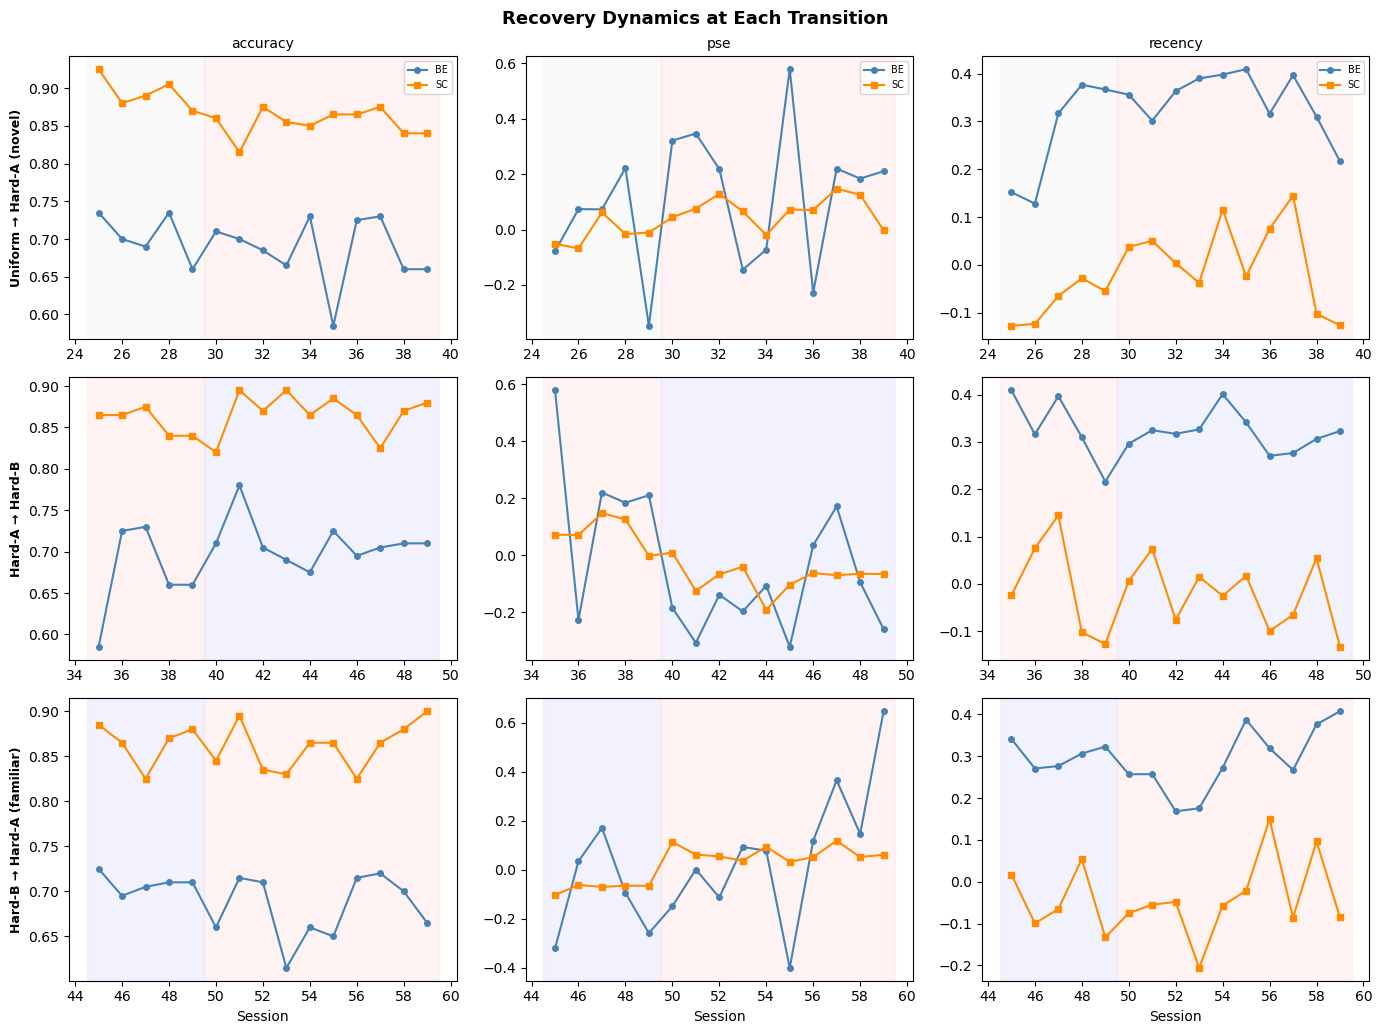

In [49]:
# Zoom into transition windows
TRANSITIONS = [
    ('Uniform → Hard-A (novel)',   25, 40),
    ('Hard-A → Hard-B',           35, 50),
    ('Hard-B → Hard-A (familiar)', 45, 60),
]

fig, axes = plt.subplots(len(TRANSITIONS), 3, figsize=(14, 3.5 * len(TRANSITIONS)))

zoom_stats = ['accuracy', 'pse', 'recency']

for row, (trans_label, s_start, s_end) in enumerate(TRANSITIONS):
    for col, stat in enumerate(zoom_stats):
        ax = axes[row, col]
        
        # Mask to transition window
        be_mask = (be_results['session_idx'] >= s_start) & (be_results['session_idx'] < s_end)
        sc_mask = (sc_results['session_idx'] >= s_start) & (sc_results['session_idx'] < s_end)
        
        if stat in be_results.columns:
            ax.plot(be_results.loc[be_mask, 'session_idx'],
                    be_results.loc[be_mask, stat],
                    'o-', ms=4, color='steelblue', label='BE')
        if stat in sc_results.columns:
            ax.plot(sc_results.loc[sc_mask, 'session_idx'],
                    sc_results.loc[sc_mask, stat],
                    's-', ms=4, color='darkorange', label='SC')
        
        # Phase shading
        for start, end, dist in phase_spans:
            if end > s_start and start < s_end:
                ax.axvspan(max(start, s_start) - 0.5,
                           min(end, s_end) - 0.5,
                           color=DIST_COLOURS.get(dist, '#f0f0f0'),
                           alpha=0.4, zorder=0)
        
        if row == 0:
            ax.set_title(stat, fontsize=10)
            ax.legend(fontsize=7)
        if col == 0:
            ax.set_ylabel(trans_label, fontsize=9, fontweight='bold')
        if row == len(TRANSITIONS) - 1:
            ax.set_xlabel('Session')

fig.suptitle('Recovery Dynamics at Each Transition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Parameter Sensitivity: What Drives Recovery Speed?

Run the same shift sequence with different learning rates to show
which parameter controls recovery timecourse.

In [50]:
# BE: vary eta_learning
eta_values = [0.15, 0.25, 0.35, 0.50, 0.70]
be_sweep = {}

for eta in eta_values:
    params = BEParams(
        sigma_percep=0.15, A_repulsion=0.10,
        eta_learning=eta, eta_relax=0.12,
    )
    be_sweep[eta] = simulate_shift_sequence(
        'BE', params, SHIFT_SEQUENCE, TRIALS_PER_SESSION,
        seed=SEED,
    )

# SC: vary gamma (note: lower gamma = more learning)
gamma_values = [0.99, 0.95, 0.90, 0.80, 0.60]
sc_sweep = {}

for gamma in gamma_values:
    params = SCParams(
        sigma_percep=0.15, A_repulsion=0.10,
        gamma=gamma, sigma_update=0.30,
    )
    sc_sweep[gamma] = simulate_shift_sequence(
        'SC', params, SHIFT_SEQUENCE, TRIALS_PER_SESSION,
        seed=SEED,
    )

print(f'BE sweep: {len(eta_values)} values')
print(f'SC sweep: {len(gamma_values)} values')

BE sweep: 5 values
SC sweep: 5 values


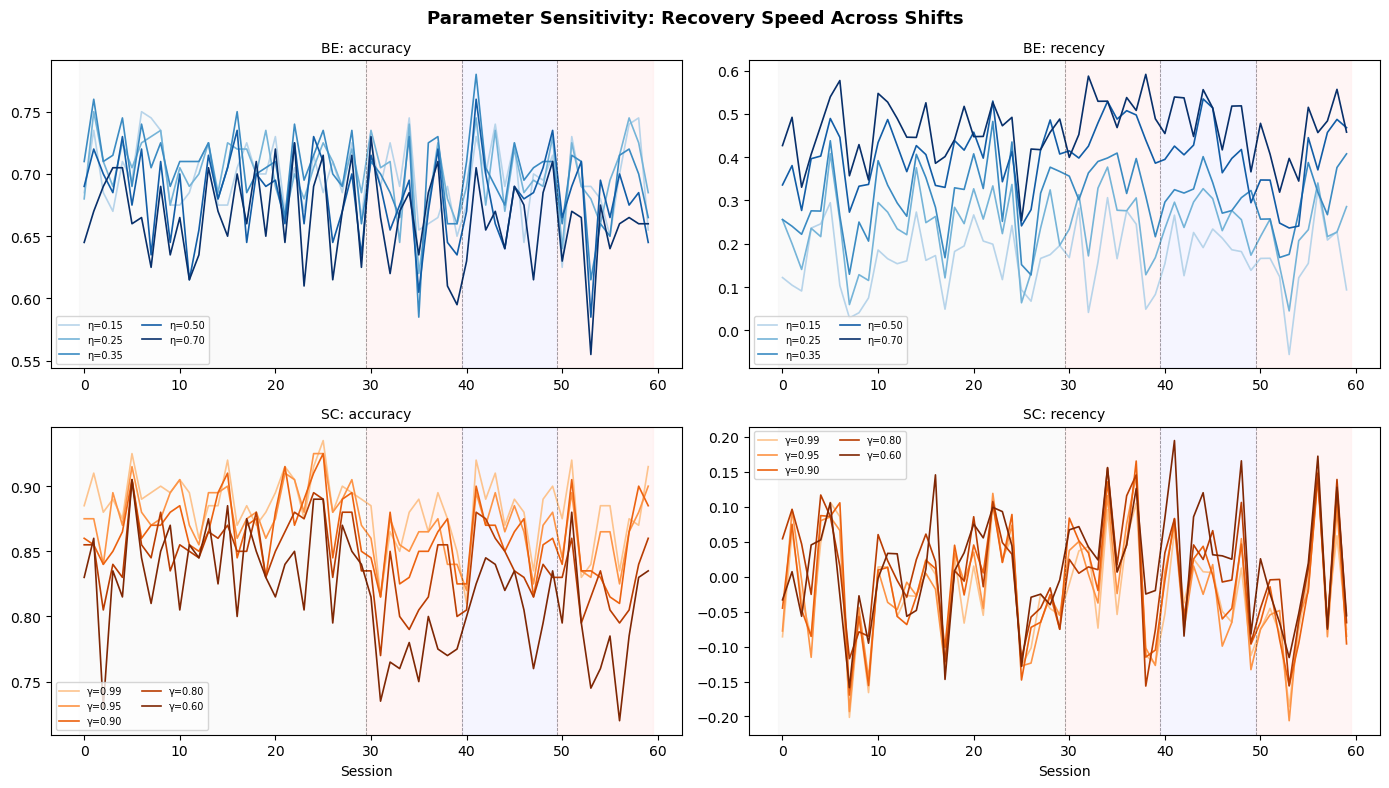

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

cmap_be = plt.cm.Blues(np.linspace(0.3, 1.0, len(eta_values)))
cmap_sc = plt.cm.Oranges(np.linspace(0.3, 1.0, len(gamma_values)))

for col, stat in enumerate(['accuracy', 'recency']):
    # BE
    ax = axes[0, col]
    for i, (eta, df) in enumerate(be_sweep.items()):
        if stat in df.columns:
            ax.plot(df['session_idx'], df[stat], '-', lw=1.2,
                    color=cmap_be[i], label=f'η={eta:.2f}')
    for b in shift_boundaries:
        ax.axvline(b - 0.5, color='black', ls='--', lw=0.6, alpha=0.4)
    for start, end, dist in phase_spans:
        ax.axvspan(start - 0.5, end - 0.5,
                   color=DIST_COLOURS.get(dist, '#f0f0f0'), alpha=0.3, zorder=0)
    ax.set_title(f'BE: {stat}', fontsize=10)
    ax.legend(fontsize=7, ncol=2)
    
    # SC
    ax = axes[1, col]
    for i, (gamma, df) in enumerate(sc_sweep.items()):
        if stat in df.columns:
            ax.plot(df['session_idx'], df[stat], '-', lw=1.2,
                    color=cmap_sc[i], label=f'γ={gamma:.2f}')
    for b in shift_boundaries:
        ax.axvline(b - 0.5, color='black', ls='--', lw=0.6, alpha=0.4)
    for start, end, dist in phase_spans:
        ax.axvspan(start - 0.5, end - 0.5,
                   color=DIST_COLOURS.get(dist, '#f0f0f0'), alpha=0.3, zorder=0)
    ax.set_title(f'SC: {stat}', fontsize=10)
    ax.legend(fontsize=7, ncol=2)
    ax.set_xlabel('Session')

fig.suptitle('Parameter Sensitivity: Recovery Speed Across Shifts',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.6 Summary of Predictions

Record the key predictions that notebook 4a should test.

In [53]:
# Quantify: recovery sessions (sessions until accuracy returns to
# within 1 SD of late-Uniform baseline)

def recovery_sessions(df, baseline_end=30, shift_start=30, stat='accuracy', threshold_sd=1.0):
    """Count sessions until stat returns to within threshold_sd of baseline."""
    bl = df[df['session_idx'] < baseline_end][stat].dropna()
    if len(bl) < 5:
        return np.nan
    bl_mean = bl.mean()
    bl_std = bl.std()
    
    post = df[df['session_idx'] >= shift_start].sort_values('session_idx')
    for _, row in post.iterrows():
        if abs(row[stat] - bl_mean) <= threshold_sd * bl_std:
            return row['session_idx'] - shift_start
    return np.nan


print('Recovery speed (sessions to return within 1 SD of Uniform baseline):')
print(f'  {"":30s} {"accuracy":>10s} {"recency":>10s}')

for label, model_name, df in [
    ('BE (η=0.35)', 'BE', be_results),
    ('SC (γ=0.95)', 'SC', sc_results),
]:
    acc_rec = recovery_sessions(df, stat='accuracy')
    rec_rec = recovery_sessions(df, stat='recency')
    print(f'  {label:30s} {acc_rec:10.0f} {rec_rec:10.0f}')

print('\n--- Predictions for 4a ---')
print('1. Accuracy should drop at each shift and recover within ~2-5 sessions')
print('2. Recency should spike at each shift (increased influence of recent trials)')
print('3. PSE may shift toward the overrepresented category')
print('4. Second Hard-A exposure should show faster recovery than first')
print('5. BE and SC predict different recovery profiles — compare real data to both')

Recovery speed (sessions to return within 1 SD of Uniform baseline):
                                   accuracy    recency
  BE (η=0.35)                             0          0
  SC (γ=0.95)                             2          0

--- Predictions for 4a ---
1. Accuracy should drop at each shift and recover within ~2-5 sessions
2. Recency should spike at each shift (increased influence of recent trials)
3. PSE may shift toward the overrepresented category
4. Second Hard-A exposure should show faster recovery than first
5. BE and SC predict different recovery profiles — compare real data to both
